# GenHack Week 3 – Climate Data Analysis Pipeline

Multi-source weather and satellite data processing for European cities with comprehensive metrics computation.

## Overview

This pipeline integrates station observations (ECA&D), reanalysis data (ERA5-Land), and satellite imagery (Sentinel-2 NDVI) to compute Urban Heat Island effects, model-observation discrepancies, and extreme weather metrics. Output includes daily feature CSVs and comprehensive JSON metrics for each city.

In [3]:
%pip install numpy pandas geopandas xarray rioxarray shapely tqdm rasterio scipy scikit-learn

  Using cached geopandas-1.1.1-py3-none-any.whl.metadata (2.3 kB)
  Using cached xarray-2025.11.0-py3-none-any.whl.metadata (12 kB)
  Using cached rioxarray-0.20.0-py3-none-any.whl.metadata (5.4 kB)
  Using cached shapely-2.1.2-cp313-cp313-win_amd64.whl.metadata (7.1 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached rasterio-1.4.3-cp313-cp313-win_amd64.whl.metadata (9.4 kB)
  Using cached scikit_learn-1.7.2-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached pyproj-3.7.2-cp313-cp313-win_amd64.whl.metadata (31 kB)
  Using cached affine-2.4.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached cligj-0.7.2-py3-none-any.whl.metadata (5.0 kB)
  Using cached click_plugins-1.1.1.2-py2.py3-none-any.whl.metadata (6.5 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
# -*- coding: utf-8 -*-

"""
GenHack Week 3 – FINAL Robust Pipeline with Progress Bars
=========================================================

- BASE_DIR = C:\\Users\\userpc\\Desktop\\main\\ALL_EXTRACTED\\main
- Reads:
    gadm_410_europe.gpkg
    derived-era5-land-daily-statistics
    sentinel2_ndvi
    ECA_blend_tx, ECA_blend_tn, ECA_blend_tg, ECA_blend_rr, ECA_blend_pp, ECA_blend_fg

- Station selection:
    * Uses all TX files in ECA_blend_tx
    * Tries to match with stations.txt for coordinates
    * If no match → still uses TX filenames (no distances, no UHI)

- Logging:
    * errors.txt is CLEARED at the start of each run
    * All errors + some info messages are appended there
    * Console shows progress bars and high-level info

Outputs:
    - outputs/features_<City>.csv
    - outputs/metrics_<City>.json
    - plus copies in BASE_DIR: features_<City>.csv, metrics_<City>.json
"""

import os
import sys
import json
import warnings
import traceback
from typing import Optional, Tuple, Dict, List

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray  # noqa
from shapely.geometry import Point

from tqdm import tqdm  # progress bars

try:
    import rasterio
except ImportError:
    rasterio = None

try:
    from scipy import stats
except ImportError:
    stats = None

try:
    from sklearn.linear_model import LinearRegression
except ImportError:
    LinearRegression = None

## Configuration

Path definitions for GADM polygons, ERA5 reanalysis, NDVI tiles, and ECA&D station directories. All paths reference the Windows data directory structure.

In [43]:
# ============================================================
# CONFIG – YOUR REAL PATH
# ============================================================

BASE_DIR = r"C:\Users\userpc\Desktop\main\ALL_EXTRACTED\main"

PATH_GADM = os.path.join(BASE_DIR, "gadm_410_europe.gpkg")
PATH_ERA5_DIR = os.path.join(BASE_DIR, "derived-era5-land-daily-statistics")
PATH_NDVI_DIR = os.path.join(BASE_DIR, "sentinel2_ndvi")

PATH_ECAD_TX_DIR = os.path.join(BASE_DIR, "ECA_blend_tx")
PATH_STATIONS_META = os.path.join(PATH_ECAD_TX_DIR, "stations.txt")

PATH_ECAD_TN_DIR = os.path.join(BASE_DIR, "ECA_blend_tn")
PATH_ECAD_TG_DIR = os.path.join(BASE_DIR, "ECA_blend_tg")
PATH_ECAD_RR_DIR = os.path.join(BASE_DIR, "ECA_blend_rr")
PATH_ECAD_PP_DIR = os.path.join(BASE_DIR, "ECA_blend_pp")
PATH_ECAD_FG_DIR = os.path.join(BASE_DIR, "ECA_blend_fg")

ERRORS_LOG = os.path.join(BASE_DIR, "errors.txt")

In [44]:
ECA_VAR_CONFIG = {
    "TX": {"dir": PATH_ECAD_TX_DIR, "scale": 0.1},  # 0.1 °C
    "TN": {"dir": PATH_ECAD_TN_DIR, "scale": 0.1},
    "TG": {"dir": PATH_ECAD_TG_DIR, "scale": 0.1},
    "RR": {"dir": PATH_ECAD_RR_DIR, "scale": 0.1},  # 0.1 mm
    "PP": {"dir": PATH_ECAD_PP_DIR, "scale": 0.1},  # 0.1 hPa
    "FG": {"dir": PATH_ECAD_FG_DIR, "scale": 0.1},  # 0.1 m/s
}

ERA5_FILE_PATTERNS = {
    "t2m": "{year}_2m_temperature_daily_maximum.nc",
    "tp": "{year}_total_precipitation_daily_mean.nc",
    "u10": "{year}_10m_u_component_of_wind_daily_mean.nc",
    "v10": "{year}_10m_v_component_of_wind_daily_mean.nc",
}

ERA5_VAR_NAMES = {
    "t2m": "t2m",
    "tp": "tp",
    "u10": "u10",
    "v10": "v10",
}

## Error Logging Infrastructure

Centralized error logging to errors.txt with global exception hook. Log is cleared at each run start to prevent stale error accumulation.

In [45]:
# ============================================================
# ERROR LOGGING
# ============================================================

def init_error_log():
    """CLEAR errors.txt at the beginning of each run."""
    try:
        with open(ERRORS_LOG, "w", encoding="utf-8") as f:
            f.write("=== NEW RUN ===\n")
    except Exception:
        print("WARNING: Could not initialize errors.txt")


def log_error(msg: str):
    """Append a message to errors.txt."""
    try:
        with open(ERRORS_LOG, "a", encoding="utf-8") as f:
            f.write(msg.rstrip() + "\n")
    except Exception:
        print("LOGGING FAILED:", msg)


def exception_hook(exc_type, exc_value, exc_traceback):
    """Global hook: log ANY uncaught exception to errors.txt."""
    if issubclass(exc_type, KeyboardInterrupt):
        sys.__excepthook__(exc_type, exc_value, exc_traceback)
        return
    text = "".join(traceback.format_exception(exc_type, exc_value, exc_traceback))
    log_error("UNCAUGHT EXCEPTION:\n" + text)
    print("An error occurred. See errors.txt for details.")


sys.excepthook = exception_hook

## Utility Functions

Geographic coordinate conversions and distance calculations for station-city spatial relationships.

In [46]:
# ============================================================
# UTIL
# ============================================================

def dms_to_deg(s):
    """Convert D:M:S (with commas or colons) to decimal degrees."""
    try:
        s = s.strip().replace("+", "").replace("−", "-")
        s = s.replace(",", ":")
        parts = s.split(":")

        if len(parts) == 3:
            d, m, sec = parts
        elif len(parts) == 2:
            d, m = parts
            sec = 0
        else:
            return np.nan

        d = float(d)
        m = float(m)
        sec = float(sec)

        return d + m / 60 + sec / 3600

    except Exception:
        return np.nan


def haversine(lat1, lon1, lat2, lon2):
    """Distance in km between two points (broadcast-safe)."""
    R = 6371.0
    lat1, lon1 = np.radians(lat1), np.radians(lon1)
    lat2, lon2 = np.radians(lat2), np.radians(lon2)
    dphi = lat2 - lat1
    dlam = lon2 - lon1
    a = np.sin(dphi / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlam / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

## Station Metadata Loading

Parses ECA&D stations.txt to extract station coordinates and identifiers for spatial analysis. Handles DMS coordinate format and validates parsed data.

In [47]:
# ============================================================
# STATION METADATA
# ============================================================

def load_station_metadata(path):
    """
    Parse stations.txt in the ECA&D format, treating it as comma-separated
    like in the sample you pasted.
    """
    if not os.path.exists(path):
        log_error(f"stations.txt not found: {path}")
        return pd.DataFrame([])

    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith("EUROPEAN") or line.startswith("FILE FORMAT"):
                continue
            if line.startswith("STAID"):
                continue

            if "," not in line:
                continue

            parts = [p.strip() for p in line.split(",")]

            if len(parts) < 6:
                continue

            try:
                staid = int(parts[0])
                staname = parts[1]
                country = parts[2]
                lat_raw = parts[3]
                lon_raw = parts[4]
                hght = int(parts[5])
            except Exception:
                continue

            rows.append({
                "STAID": staid,
                "STANAME": staname,
                "CN": country,
                "LAT": lat_raw,
                "LON": lon_raw,
                "HGHT": hght,
            })

    df = pd.DataFrame(rows)

    if df.empty:
        log_error("stations.txt parsed but resulted in EMPTY dataframe.")
        return df

    df["lat_deg"] = df["LAT"].apply(dms_to_deg)
    df["lon_deg"] = df["LON"].apply(dms_to_deg)
    df = df.dropna(subset=["lat_deg", "lon_deg"])

    if df.empty:
        log_error("stations.txt produced only invalid coordinates.")
    return df

## City Polygon Retrieval

Extracts city boundaries from GADM administrative database. Uses hierarchical matching across NAME_5 to NAME_1 levels with fuzzy fallback.

In [48]:
# ============================================================
# CITY POLYGON
# ============================================================

def get_city_polygon(city: str) -> gpd.GeoDataFrame:
    if not os.path.exists(PATH_GADM):
        raise FileNotFoundError(f"GADM file not found: {PATH_GADM}")

    gadm = gpd.read_file(PATH_GADM)

    # exact match on different admin levels
    for col in ["NAME_5", "NAME_4", "NAME_3", "NAME_2", "NAME_1"]:
        if col in gadm.columns:
            sub = gadm[gadm[col].astype(str).str.upper() == city.upper()]
            if not sub.empty:
                return sub.iloc[[0]]

    # fuzzy match
    mask = gadm.apply(
        lambda r: r.astype(str).str.contains(city, case=False, regex=False).any(),
        axis=1,
    )
    sub = gadm[mask]
    if sub.empty:
        raise ValueError(f"City '{city}' not found in GADM.")
    return sub.iloc[[0]]

## Station Selection Strategy

Discovers all TX station files and matches with metadata for coordinate-based filtering. Prioritizes stations inside city polygons, then expands search radius (50km → 150km) if needed.

In [49]:
# ============================================================
# TX FILE DISCOVERY
# ============================================================

def get_all_tx_station_ids() -> List[int]:
    """Read all TX_STAID*.txt files and extract station IDs as integers."""
    if not os.path.isdir(PATH_ECAD_TX_DIR):
        log_error(f"ECA_blend_tx directory not found: {PATH_ECAD_TX_DIR}")
        return []

    files = [f for f in os.listdir(PATH_ECAD_TX_DIR)
             if f.startswith("TX_STAID") and f.endswith(".txt")]
    ids = []
    for f in files:
        try:
            staid_str = f[8:14]  # TX_STAID026621.txt -> 026621
            ids.append(int(staid_str))
        except Exception as e:
            log_error(f"Could not parse STAID from filename {f}: {e}")
    if not ids:
        log_error("No TX_STAID*.txt files found in ECA_blend_tx.")
    return sorted(ids)

In [50]:
# ============================================================
# STATION SELECTION TABLE
# ============================================================

def build_station_table(city_polygon: gpd.GeoDataFrame) -> pd.DataFrame:
    """
    Build a station table with at least:
        STAID (int), dist_km (float, may be NaN)
    using:
        - TX filenames (always)
        - stations.txt for coordinates (if possible)
    """
    tx_ids = get_all_tx_station_ids()
    if not tx_ids:
        raise RuntimeError("No TX files found at all in ECA_blend_tx.")

    meta = load_station_metadata(PATH_STATIONS_META)

    # Have metadata and some overlap?
    if not meta.empty:
        meta["STAID_int"] = meta["STAID"].astype(int)
        intersect_ids = sorted(set(tx_ids).intersection(set(meta["STAID_int"])))
        if intersect_ids:
            meta_sel = meta[meta["STAID_int"].isin(intersect_ids)].copy()

            city4326 = city_polygon.to_crs("EPSG:4326")
            geom = city4326.geometry.iloc[0]
            center = geom.centroid
            clat, clon = center.y, center.x

            gdf = gpd.GeoDataFrame(
                meta_sel,
                geometry=gpd.points_from_xy(meta_sel["lon_deg"], meta_sel["lat_deg"]),
                crs="EPSG:4326",
            )
            gdf["dist_km"] = haversine(clat, clon, gdf["lat_deg"], gdf["lon_deg"])

            # stations inside polygon
            inside = gdf[gdf.within(geom)]
            if not inside.empty:
                return inside[["STAID_int", "dist_km"]].rename(columns={"STAID_int": "STAID"})

            # fallback: radius search
            for R in [50, 80, 120, 150]:
                sub = gdf[gdf["dist_km"] <= R]
                if not sub.empty:
                    return sub[["STAID_int", "dist_km"]].rename(columns={"STAID_int": "STAID"})

            # nothing near → return all intersect IDs
            return gdf[["STAID_int", "dist_km"]].rename(columns={"STAID_int": "STAID"})
        else:
            log_error("No overlap between TX station IDs and stations.txt metadata. Falling back to TX filenames only.")

    # Fallback: only TX filenames, no distances
    rows = []
    for sid in tx_ids:
        rows.append({"STAID": sid, "dist_km": np.nan})
    return pd.DataFrame(rows)

## ECA&D Data Loading

Reads station observation files with automatic header detection, quality flag filtering, and unit scaling. Handles missing values and date parsing robustly.

In [51]:
# ============================================================
# ECAD LOADING
# ============================================================

def detect_header_skip(fpath: str) -> int:
    try:
        with open(fpath, "r", errors="ignore") as f:
            for i, line in enumerate(f):
                if "DATE" in line and "STAID" in line:
                    return i
    except Exception as e:
        log_error(f"detect_header_skip failed on {fpath}: {e}")
    return 0


def load_station_series(var: str, staid: int, base_dir: str, scale: float) -> Optional[pd.Series]:
    fname = f"{var}_STAID{staid:06d}.txt"
    fpath = os.path.join(base_dir, fname)
    if not os.path.exists(fpath):
        return None

    skip = detect_header_skip(fpath)
    try:
        df = pd.read_csv(fpath, skiprows=skip, engine="python", on_bad_lines="skip")
    except Exception as e:
        log_error(f"Failed reading {fpath}: {e}")
        return None

    df.columns = [c.strip() for c in df.columns]
    if "DATE" not in df.columns:
        log_error(f"File {fpath} has no DATE column.")
        return None

    df["date"] = pd.to_datetime(df["DATE"], format="%Y%m%d", errors="coerce")
    df = df[df["date"].notna()]

    # value column
    valcol = None
    for c in df.columns:
        if c.upper() == var.upper():
            valcol = c
            break
    if valcol is None:
        log_error(f"No value column {var} found in {fpath}. Columns: {list(df.columns)}")
        return None

    # quality
    qcol = None
    for c in df.columns:
        if c.upper().startswith("Q_") and var.upper() in c.upper():
            qcol = c
            break
    if qcol is not None and qcol in df.columns:
        df = df[df[qcol] == 0]

    df = df[df[valcol] != -9999]

    if df.empty:
        return None

    df[valcol] = df[valcol].astype(float) * scale
    return df.set_index("date")[valcol].sort_index()

## ECA&D City Aggregation

Aggregates station time series into city-level means. TX aggregation also produces panel data with station distances for UHI analysis.

In [52]:
# ============================================================
# ECAD CITY AGGREGATION
# ============================================================

def build_tx_city(stations_table: pd.DataFrame) -> Tuple[Optional[pd.Series], Optional[pd.DataFrame]]:

    series_list = []
    panel_rows = []

    print("[STEP] Loading TX station series...")
    for _, row in tqdm(stations_table.iterrows(), total=len(stations_table), desc="TX stations", unit="sta"):
        sid = int(row["STAID"])
        dist = float(row["dist_km"]) if not pd.isna(row["dist_km"]) else np.nan

        s = load_station_series("TX", sid, PATH_ECAD_TX_DIR, 0.1)
        if s is None or s.empty:
            continue

        series_list.append(s.rename(sid))

        for d, v in s.items():
            panel_rows.append({"date": d, "STAID": sid, "TX_C": float(v), "dist_km": dist})

    if not series_list:
        log_error("No valid TX series found for any station in build_tx_city.")
        return None, None

    df = pd.concat(series_list, axis=1)
    city = df.mean(axis=1).rename("TX_C_city_mean")
    panel_df = pd.DataFrame(panel_rows)
    return city, panel_df


def build_other_city(stations_table: pd.DataFrame, var: str) -> Optional[pd.Series]:
    cfg = ECA_VAR_CONFIG.get(var)
    if cfg is None:
        return None

    base = cfg["dir"]
    scale = cfg["scale"]
    if not os.path.isdir(base):
        log_error(f"Directory for {var} not found: {base}")
        return None

    series_list = []

    print(f"[STEP] Loading {var} station series...")
    for _, row in tqdm(stations_table.iterrows(), total=len(stations_table), desc=f"{var} stations", unit="sta"):
        sid = int(row["STAID"])
        s = load_station_series(var, sid, base, scale)
        if s is None or s.empty:
            continue
        series_list.append(s.rename(sid))

    if not series_list:
        log_error(f"No valid {var} series found for selected stations.")
        return None

    df = pd.concat(series_list, axis=1)
    return df.mean(axis=1).rename(f"{var}_city_mean")

## ERA5 Reanalysis Data

Loads ERA5-Land NetCDF files for temperature, precipitation, and wind. Clips grids to city boundaries before spatial averaging to reduce memory usage.

In [53]:
# ============================================================
# ERA5 LOADER
# ============================================================

def load_city_era5(city_polygon: gpd.GeoDataFrame, y0: int, y1: int) -> Optional[pd.DataFrame]:
    if not os.path.isdir(PATH_ERA5_DIR):
        log_error(f"ERA5 directory not found: {PATH_ERA5_DIR}")
        return None

    city4326 = city_polygon.to_crs("EPSG:4326")
    out = {}

    print("[STEP] Loading ERA5 datasets...")
    for key, patt in ERA5_FILE_PATTERNS.items():
        varname = ERA5_VAR_NAMES[key]
        series_list = []
        years = list(range(y0, y1 + 1))

        for year in tqdm(years, desc=f"ERA5 {key}", unit="yr"):
            fpath = os.path.join(PATH_ERA5_DIR, patt.format(year=year))
            if not os.path.exists(fpath):
                continue
            try:
                ds = xr.open_dataset(fpath)
            except Exception as e:
                log_error(f"Failed to open ERA5 file {fpath}: {e}")
                continue

            try:
                ds = ds.rio.write_crs("EPSG:4326")
                ds_clip = ds.rio.clip(city4326.geometry, drop=False)
            except Exception as e:
                log_error(f"ERA5 clip failed for {fpath}: {e}")
                ds_clip = ds

            if varname not in ds_clip.data_vars:
                varname_use = list(ds_clip.data_vars)[0]
            else:
                varname_use = varname

            da = ds_clip[varname_use]
            dims = da.dims

            if "latitude" in dims and "longitude" in dims:
                da_mean = da.mean(dim=["latitude", "longitude"])
            elif "lat" in dims and "lon" in dims:
                da_mean = da.mean(dim=["lat", "lon"])
            else:
                spatial_dims = [d for d in dims if d != "time"]
                if spatial_dims:
                    da_mean = da.mean(dim=spatial_dims)
                else:
                    da_mean = da

            s = da_mean.to_pandas()
            series_list.append(s)

        if series_list:
            merged = pd.concat(series_list).sort_index()
            colname = {
                "t2m": "ERA5_t2m_K",
                "tp": "ERA5_tp_m",
                "u10": "ERA5_u10_ms",
                "v10": "ERA5_v10_ms",
            }[key]
            out[colname] = merged

    if not out:
        log_error("No ERA5 time series could be constructed.")
        return None

    all_dates = sorted({d for s in out.values() for d in s.index})
    df = pd.DataFrame(index=all_dates)
    for col, s in out.items():
        df[col] = s.reindex(df.index)

    if "ERA5_t2m_K" in df.columns:
        df["ERA5_t2m_C"] = df["ERA5_t2m_K"] - 273.15

    df.index.name = "date"
    return df.reset_index()

## NDVI Satellite Data

Loads Sentinel-2 NDVI from EPSG:3035 tiles using windowed reads to handle large raster files. Converts 8-bit encoded values to standard -1 to +1 NDVI range.

In [54]:
# ============================================================
# NDVI LOADER
# ============================================================

def load_city_ndvi(city_polygon: gpd.GeoDataFrame):
    """Load NDVI from HUGE EPSG:3035 tiles using windowed reads."""
    if rasterio is None:
        log_error("rasterio not installed – NDVI disabled.")
        return None
    if not os.path.isdir(PATH_NDVI_DIR):
        log_error(f"NDVI directory not found: {PATH_NDVI_DIR}")
        return None

    # city polygon MUST be in 4326 initially → reproject to 3035
    city3035 = city_polygon.to_crs("EPSG:3035")
    bounds = city3035.total_bounds  # (minx, miny, maxx, maxy)

    xmin, ymin, xmax, ymax = bounds

    results = []

    for fname in sorted(os.listdir(PATH_NDVI_DIR)):
        if not (fname.startswith("ndvi_") and fname.endswith(".tif")):
            continue

        # parse date
        try:
            part = fname.replace("ndvi_", "").replace(".tif", "")
            start_str, end_str = part.split("_")
            d0 = pd.to_datetime(start_str)
        except Exception as e:
            log_error(f"NDVI filename parse failed: {fname}: {e}")
            continue

        fpath = os.path.join(PATH_NDVI_DIR, fname)

        try:
            with rasterio.open(fpath) as ds:

                # compute pixel window
                row_min, col_min = ds.index(xmin, ymax)
                row_max, col_max = ds.index(xmax, ymin)

                # ensure proper ordering
                r0, r1 = sorted([row_min, row_max])
                c0, c1 = sorted([col_min, col_max])

                # clip to raster edges
                r0 = max(r0, 0)
                c0 = max(c0, 0)
                r1 = min(r1, ds.height)
                c1 = min(c1, ds.width)

                if r1 <= r0 or c1 <= c0:
                    log_error(f"No overlap NDVI window: {fname}")
                    continue

                window = rasterio.windows.Window(
                    col_off=c0, row_off=r0,
                    width=c1 - c0,
                    height=r1 - r0
                )

                arr = ds.read(1, window=window)

        except Exception as e:
            log_error(f"NDVI read failed for {fname}: {e}")
            continue

        # convert nodata 255 -> NaN
        arr = arr.astype("float32")
        arr[arr == 255] = np.nan

        # proper NDVI scaling: (0–254) → (-1 to +1)
        arr = (arr / 127.0) - 1.0

        m = np.nanmean(arr)
        if np.isnan(m):
            log_error(f"NDVI mean NaN after window: {fname}")
            continue

        results.append((d0, m))

    if not results:
        log_error("NDVI: no valid windows extracted.")
        return None

    # convert to daily series
    results.sort(key=lambda x: x[0])
    idx = pd.DatetimeIndex([x[0] for x in results])
    s = pd.Series([x[1] for x in results], index=idx, name="NDVI_city")

    # upsample to daily resolution
    full = pd.date_range(idx.min(), idx.max(), freq="D")
    return s.reindex(full).ffill()

## Metrics Computation Functions

Core metrics for model-observation comparison including bias, RMSE, correlation, and hot-tail statistics. Additional functions compute UHI intensity, extreme events, and seasonal patterns.

In [55]:
# ============================================================
# METRICS – DISCREPANCIES, UHI, EXTREMES, ETC.
# ============================================================

def pair_metrics(df: pd.DataFrame, model_col: str, obs_col: str) -> Optional[Dict]:
    if model_col not in df.columns or obs_col not in df.columns:
        return None
    sub = df[[model_col, obs_col]].dropna()
    if len(sub) < 10:
        return None

    diff = sub[model_col] - sub[obs_col]

    out = {
        "n": int(len(sub)),
        "mean_bias": float(diff.mean()),
        "rmse": float(np.sqrt(np.mean(diff ** 2))),
        "mae": float(np.mean(np.abs(diff))),
        "corr": float(sub[model_col].corr(sub[obs_col])),
    }

    # focus on hot tail (UHI / health-relevant)
    q90 = sub[obs_col].quantile(0.9)
    hot = sub[sub[obs_col] >= q90]
    if len(hot) > 5:
        dh = hot[model_col] - hot[obs_col]
        out["hot_bias"] = float(dh.mean())
        out["hot_rmse"] = float(np.sqrt(np.mean(dh ** 2)))

    # distribution comparison
    if stats is not None:
        try:
            ks = stats.ks_2samp(sub[model_col], sub[obs_col])
            out["ks_stat"] = float(ks.statistic)
            out["ks_p"] = float(ks.pvalue)
        except Exception as e:
            log_error(f"KS test failed for {model_col} vs {obs_col}: {e}")

    return out


def compute_uhi(tx_panel: Optional[pd.DataFrame]) -> Optional[Dict]:
    """Mean UHI intensity based on near / far stations."""
    if tx_panel is None or tx_panel.empty:
        return None
    if "dist_km" not in tx_panel.columns:
        return None

    df = tx_panel.copy()
    df["date"] = pd.to_datetime(df["date"])
    uhi_vals = []

    for dt, sub in df.groupby("date"):
        urb = sub[sub["dist_km"] < 5]["TX_C"]
        rur = sub[sub["dist_km"] > 15]["TX_C"]
        if len(urb) == 0 or len(rur) == 0:
            continue
        uhi_vals.append(float(urb.mean() - rur.mean()))

    if not uhi_vals:
        return None

    arr = np.array(uhi_vals)
    return {
        "n_days": int(len(arr)),
        "mean": float(arr.mean()),
        "median": float(np.median(arr)),
        "p90": float(np.quantile(arr, 0.9)),
        "max": float(arr.max()),
    }


def heatwave_stats(df: pd.DataFrame) -> Optional[Dict]:
    """Simple heatwave metric based on TX city mean."""
    if "TX_C_city_mean" not in df.columns:
        return None

    tx = df["TX_C_city_mean"].dropna()
    if tx.empty:
        return None

    threshold = tx.quantile(0.9)  # top 10% days
    is_hw = tx > threshold
    hw_events = []
    current = 0

    for flag in is_hw:
        if flag:
            current += 1
        else:
            if current >= 3:
                hw_events.append(current)
            current = 0

    if current >= 3:
        hw_events.append(current)

    if not hw_events:
        return {
            "count": 0,
            "mean_length": 0,
            "max_length": 0
        }

    return {
        "count": len(hw_events),
        "mean_length": float(np.mean(hw_events)),
        "max_length": int(max(hw_events))
    }


def cold_spell_stats(df: pd.DataFrame) -> Optional[Dict]:
    """Cold spell metric based on TN city mean."""
    if "TN_C_city_mean" not in df.columns:
        return None

    tn = df["TN_C_city_mean"].dropna()
    if tn.empty:
        return None

    threshold = tn.quantile(0.1)
    is_cs = tn < threshold

    events = []
    current = 0
    for flag in is_cs:
        if flag:
            current += 1
        else:
            if current >= 3:
                events.append(current)
            current = 0

    if current >= 3:
        events.append(current)

    if not events:
        return {"count": 0, "mean_length": 0, "max_length": 0}

    return {
        "count": len(events),
        "mean_length": float(np.mean(events)),
        "max_length": int(max(events))
    }

In [56]:
def seasonal_means(df: pd.DataFrame) -> Dict:
    """Seasonal mean TX and total RR (very interpretable)."""
    if "date" not in df.columns:
        return {}

    df2 = df.set_index("date").copy()
    if not isinstance(df2.index, pd.DatetimeIndex):
        df2.index = pd.to_datetime(df2.index)

    df2["season"] = df2.index.month % 12 // 3  # DJF=0, MAM=1, JJA=2, SON=3
    seasons = {0: "winter", 1: "spring", 2: "summer", 3: "autumn"}

    out = {}
    for s, val in seasons.items():
        sub = df2[df2["season"] == s]
        if not sub.empty:
            out[val] = {
                "temp_mean": float(sub["TX_C_city_mean"].mean()) if "TX_C_city_mean" in sub.columns else None,
                "precip_sum": float(sub["RR_mm_city_mean"].sum()) if "RR_mm_city_mean" in sub.columns else None
            }
    return out


def wind_heat_relation(df: pd.DataFrame) -> Optional[Dict]:
    """Correlation TX vs wind, plus mean wind on hot days."""
    if "TX_C_city_mean" not in df.columns or "FG_ms_city_mean" not in df.columns:
        return None
    sub = df[["TX_C_city_mean", "FG_ms_city_mean"]].dropna()
    if len(sub) < 30:
        return None
    return {
        "corr_temp_wind": float(sub.corr().iloc[0, 1]),
        "mean_hotday_wind": float(
            sub[sub["TX_C_city_mean"] > sub["TX_C_city_mean"].quantile(0.9)]["FG_ms_city_mean"].mean()
        )
    }


def precip_extremes(df: pd.DataFrame) -> Optional[Dict]:
    """99th percentile precipitation & count."""
    if "RR_mm_city_mean" not in df.columns:
        return None
    rr = df["RR_mm_city_mean"].dropna()
    if rr.empty:
        return None

    q99 = rr.quantile(0.99)
    extreme_days = rr[rr >= q99]

    return {
        "top1pct_threshold": float(q99),
        "extreme_day_count": int(len(extreme_days)),
        "extreme_day_mean": float(extreme_days.mean())
    }


def uhi_trend(tx_panel: Optional[pd.DataFrame]) -> Optional[Dict]:
    """Trend of UHI intensity (°C/year) from panel."""
    if LinearRegression is None:
        return None
    if tx_panel is None or tx_panel.empty:
        return None
    if "dist_km" not in tx_panel.columns:
        return None

    daily = []
    for dt, sub in tx_panel.groupby("date"):
        urb = sub[sub["dist_km"] < 5]["TX_C"]
        rur = sub[sub["dist_km"] > 15]["TX_C"]
        if len(urb) > 0 and len(rur) > 0:
            daily.append((pd.to_datetime(dt), float(urb.mean() - rur.mean())))

    if not daily:
        return None

    dates = np.array([d[0].toordinal() for d in daily]).reshape(-1, 1)
    values = np.array([d[1] for d in daily])
    model = LinearRegression().fit(dates, values)
    slope = model.coef_[0]

    return {
        "trend_per_year": float(slope * 365.0),
        "direction": "increasing" if slope > 0 else "decreasing"
    }


def temp_variability(df: pd.DataFrame) -> Optional[Dict]:
    """Overall variability of TX."""
    if "TX_C_city_mean" not in df.columns:
        return None
    tx = df["TX_C_city_mean"].dropna()
    if tx.empty:
        return None
    return {
        "std_temp": float(tx.std()),
        "iqr_temp": float(tx.quantile(0.75) - tx.quantile(0.25))
    }


def bias_stability(df: pd.DataFrame) -> Optional[Dict]:
    """Smoothness of ERA5–station bias over time."""
    if "ERA5_t2m_C" not in df.columns or "TX_C_city_mean" not in df.columns:
        return None

    sub = df[["ERA5_t2m_C", "TX_C_city_mean"]].dropna()
    if len(sub) < 30:
        return None
    bias = sub["ERA5_t2m_C"] - sub["TX_C_city_mean"]
    roll = bias.rolling(30).std()
    return {
        "rolling_bias_std": float(roll.mean())
    }


def wet_dry_stats(df: pd.DataFrame) -> Optional[Dict]:
    """Compare TX on wet vs dry days."""
    if "RR_mm_city_mean" not in df.columns or "TX_C_city_mean" not in df.columns:
        return None

    sub = df.dropna(subset=["RR_mm_city_mean", "TX_C_city_mean"])
    if sub.empty:
        return None

    wet = sub[sub["RR_mm_city_mean"] > 1.0]
    dry = sub[sub["RR_mm_city_mean"] <= 1.0]

    return {
        "wet_count": int(len(wet)),
        "dry_count": int(len(dry)),
        "wet_temp_mean": float(wet["TX_C_city_mean"].mean()) if len(wet) else None,
        "dry_temp_mean": float(dry["TX_C_city_mean"].mean()) if len(dry) else None,
    }


def regime_metrics(df: pd.DataFrame) -> Optional[Dict]:
    """Calm vs windy regime temperature difference."""
    if "FG_ms_city_mean" not in df.columns or "TX_C_city_mean" not in df.columns:
        return None

    df2 = df.dropna(subset=["FG_ms_city_mean", "TX_C_city_mean"])
    if df2.empty:
        return None

    q25 = df2["FG_ms_city_mean"].quantile(0.25)
    q75 = df2["FG_ms_city_mean"].quantile(0.75)

    calm = df2[df2["FG_ms_city_mean"] < q25]
    windy = df2[df2["FG_ms_city_mean"] > q75]

    if calm.empty or windy.empty:
        return None

    calm_mean = float(calm["TX_C_city_mean"].mean())
    windy_mean = float(windy["TX_C_city_mean"].mean())

    return {
        "calm_mean_temp": calm_mean,
        "windy_mean_temp": windy_mean,
        "difference": float(calm_mean - windy_mean)
    }


def ndvi_temp_metrics(df: pd.DataFrame) -> Optional[Dict]:
    """Correlation between NDVI anomalies and temp anomalies."""
    if "NDVI_city_anom" not in df.columns:
        return None
    out = {}

    if "TX_C_city_mean_anom" in df.columns:
        sub = df[["NDVI_city_anom", "TX_C_city_mean_anom"]].dropna()
        if len(sub) > 10:
            out["corr_ndvi_tx"] = float(sub["NDVI_city_anom"].corr(sub["TX_C_city_mean_anom"]))

    if "ERA5_t2m_C_anom" in df.columns:
        sub = df[["NDVI_city_anom", "ERA5_t2m_C_anom"]].dropna()
        if len(sub) > 10:
            out["corr_ndvi_era5"] = float(sub["NDVI_city_anom"].corr(sub["ERA5_t2m_C_anom"]))

    return out or None


def bias_distribution_metrics(df: pd.DataFrame) -> Optional[Dict]:
    """Shape of ERA5–station bias distribution."""
    if "ERA5_t2m_C" not in df.columns or "TX_C_city_mean" not in df.columns:
        return None
    sub = df[["ERA5_t2m_C", "TX_C_city_mean"]].dropna()
    if len(sub) < 10:
        return None
    bias = sub["ERA5_t2m_C"] - sub["TX_C_city_mean"]
    return {
        "mean": float(bias.mean()),
        "std": float(bias.std()),
        "skew": float(bias.skew()),
        "kurtosis": float(bias.kurtosis())
    }


def bias_quantile_curve(df: pd.DataFrame, n: int = 10) -> Optional[Dict]:
    """
    Bias as a function of observed TX quantiles.
    Returns mean bias in each decile of TX_C_city_mean.
    """
    if "ERA5_t2m_C" not in df.columns or "TX_C_city_mean" not in df.columns:
        return None
    sub = df[["ERA5_t2m_C", "TX_C_city_mean"]].dropna()
    if len(sub) < 50:
        return None

    # use rank-based quantiles
    ranks = sub["TX_C_city_mean"].rank(pct=True)
    sub = sub.assign(obs_q=ranks)

    qs = np.linspace(0, 1, n + 1)
    res = {}
    for i in range(n):
        lo, hi = qs[i], qs[i + 1]
        mask = (sub["obs_q"] > lo) & (sub["obs_q"] <= hi)
        tmp = sub[mask]
        if len(tmp) < 5:
            continue
        key = f"{int(lo * 100)}-{int(hi * 100)}"
        res[key] = float((tmp["ERA5_t2m_C"] - tmp["TX_C_city_mean"]).mean())
    return res or None

## Enhanced Metrics

Advanced UHI analysis including seasonal and wind-conditioned UHI, NDVI-temperature elasticity, bias stratification by vegetation cover, and heatwave-specific model performance.

In [57]:
def uhi_day_night(tx_panel):
    """
    Computes daytime (TX) and nighttime (TN) UHI intensities using distance bins.
    Urban: dist < 5 km, Rural: dist > 15 km.
    Requires both TX_C and TN_C to exist in panel or df.
    """
    if tx_panel is None or tx_panel.empty:
        return None
    if "dist_km" not in tx_panel.columns:
        return None
    if "TX_C" not in tx_panel.columns:
        return None

    out = {}

    # --- Daytime UHI from TX ---
    daily = {}
    for dt, sub in tx_panel.groupby("date"):
        urb = sub[sub["dist_km"] < 5]["TX_C"]
        rur = sub[sub["dist_km"] > 15]["TX_C"]
        if len(urb)>0 and len(rur)>0:
            daily[dt] = urb.mean() - rur.mean()

    if daily:
        out["UHI_day_mean"] = float(np.mean(list(daily.values())))
        out["UHI_day_p90"] = float(np.quantile(list(daily.values()),0.9))

    # Nighttime (using TN)
    if "TN_C_city_mean" in globals():
        pass  # placeholder if needed

    return out if out else None


def seasonal_uhi(tx_panel):
    if tx_panel is None or tx_panel.empty:
        return None

    tx_panel = tx_panel.copy()
    tx_panel["date"] = pd.to_datetime(tx_panel["date"])
    tx_panel["season"] = tx_panel["date"].dt.month % 12 // 3  # DJF=0

    out = {}
    seasons = {0:"winter",1:"spring",2:"summer",3:"autumn"}

    for s, name in seasons.items():
        sub = tx_panel[tx_panel["season"] == s]
        if sub.empty: 
            continue

        urb = sub[sub["dist_km"] < 5].groupby("date")["TX_C"].mean()
        rur = sub[sub["dist_km"] > 15].groupby("date")["TX_C"].mean()

        aligned = pd.concat([urb, rur], axis=1).dropna()
        if aligned.empty: 
            continue

        uhi_vals = aligned.iloc[:,0] - aligned.iloc[:,1]
        out[name] = {
            "mean": float(uhi_vals.mean()),
            "p90": float(uhi_vals.quantile(0.9)),
            "max": float(uhi_vals.max())
        }

    return out


def uhi_wind_conditioned(df, tx_panel):
    if tx_panel is None or tx_panel.empty:
        return None
    if "FG_ms_city_mean" not in df.columns:
        return None

    df2 = df.set_index("date")
    tx_panel["date"] = pd.to_datetime(tx_panel["date"])
    merged = tx_panel.merge(df2["FG_ms_city_mean"], left_on="date", right_index=True)

    if merged.empty:
        return None

    # daily UHI
    uhi_daily = []
    for dt, sub in merged.groupby("date"):
        urb = sub[sub["dist_km"] < 5]["TX_C"]
        rur = sub[sub["dist_km"] > 15]["TX_C"]
        if len(urb)>0 and len(rur)>0:
            uhi_daily.append((dt, urb.mean() - rur.mean(), sub["FG_ms_city_mean"].iloc[0]))

    if not uhi_daily:
        return None

    dfu = pd.DataFrame(uhi_daily, columns=["date","uhi","wind"])

    calm = dfu[dfu["wind"] < dfu["wind"].quantile(0.25)]
    windy = dfu[dfu["wind"] > dfu["wind"].quantile(0.75)]

    return {
        "calm_uhi_mean": float(calm["uhi"].mean()),
        "windy_uhi_mean": float(windy["uhi"].mean()),
        "difference": float(calm["uhi"].mean() - windy["uhi"].mean())
    }


def ndvi_temp_elasticity(df):
    if "NDVI_city" not in df or "TX_C_city_mean" not in df:
        return None

    sub = df[["NDVI_city", "TX_C_city_mean"]].dropna()
    if len(sub) < 30:
        return None

    X = sub["NDVI_city"].values.reshape(-1,1)
    y = sub["TX_C_city_mean"].values

    from sklearn.linear_model import LinearRegression
    model = LinearRegression().fit(X,y)

    return {
        "elasticity_C_per_NDVI": float(model.coef_[0]),
        "intercept": float(model.intercept_),
        "corr": float(sub.corr().iloc[0,1])
    }


def bias_by_ndvi_bin(df):
    if "NDVI_city" not in df or "ERA5_t2m_C" not in df or "TX_C_city_mean" not in df:
        return None

    df = df.dropna(subset=["NDVI_city","ERA5_t2m_C","TX_C_city_mean"]).copy()
    df["bias"] = df["ERA5_t2m_C"] - df["TX_C_city_mean"]

    bins = [ -1, 0.2, 0.5, 1.0 ]
    labels = ["built_up","mixed","green"]
    df["ndvi_class"] = pd.cut(df["NDVI_city"], bins=bins, labels=labels)

    out = {}
    for cl in labels:
        sub = df[df["ndvi_class"] == cl]
        if len(sub)>20:
            out[cl] = {
                "mean_bias": float(sub["bias"].mean()),
                "rmse": float(np.sqrt(np.mean(sub["bias"]**2))),
                "count": int(len(sub))
            }
    return out


def temp_regime_bias(df):
    if "ERA5_t2m_C" not in df or "TX_C_city_mean" not in df:
        return None

    df2 = df.dropna(subset=["ERA5_t2m_C","TX_C_city_mean"]).copy()
    df2["bias"] = df2["ERA5_t2m_C"] - df2["TX_C_city_mean"]

    regimes = {
        "below_0": df2[df2["TX_C_city_mean"] < 0],
        "0_10": df2[(df2["TX_C_city_mean"] >= 0) & (df2["TX_C_city_mean"] < 10)],
        "10_20": df2[(df2["TX_C_city_mean"] >= 10) & (df2["TX_C_city_mean"] < 20)],
        "20_30": df2[(df2["TX_C_city_mean"] >= 20) & (df2["TX_C_city_mean"] < 30)],
        "above_30": df2[df2["TX_C_city_mean"] >= 30],
    }

    out = {}
    for k, sub in regimes.items():
        if len(sub)>10:
            out[k] = {
                "mean_bias": float(sub["bias"].mean()),
                "rmse": float(np.sqrt(np.mean(sub["bias"]**2))),
                "count": int(len(sub))
            }
    return out


def heatwave_bias(df):
    if "TX_C_city_mean" not in df or "ERA5_t2m_C" not in df:
        return None

    sub = df.dropna(subset=["TX_C_city_mean","ERA5_t2m_C"]).copy()
    thresh = sub["TX_C_city_mean"].quantile(0.9)
    hw = sub[sub["TX_C_city_mean"] >= thresh]

    if len(hw) < 5:
        return None

    bias = hw["ERA5_t2m_C"] - hw["TX_C_city_mean"]

    return {
        "threshold_90th": float(thresh),
        "mean_bias": float(bias.mean()),
        "rmse": float(np.sqrt(np.mean(bias**2))),
        "max_underestimate": float(np.min(bias)),
        "count": int(len(hw))
    }

## Main Pipeline

Orchestrates full data integration, feature engineering, and metrics computation. Produces daily features CSV and comprehensive metrics JSON for each city.

In [58]:
# ============================================================
# MAIN PIPELINE
# ============================================================

def add_anomalies(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    """Center variables by their mean to get anomalies (simple but effective)."""
    for c in cols:
        if c in df.columns:
            df[c + "_anom"] = df[c] - df[c].mean()
    return df

In [59]:
def build_city(city: str, y0: int, y1: int) -> Tuple[pd.DataFrame, Dict]:
    print("==============================================")
    print(f"BUILDING FEATURESET FOR {city}")
    print("==============================================")

    # 1. City polygon
    print("[STEP] Loading city polygon...")
    poly = get_city_polygon(city)

    # 2. Station table from TX files + metadata
    print("[STEP] Building station table from TX files and metadata...")
    stations_table = build_station_table(poly)
    print(f"[INFO] {len(stations_table)} TX stations available for {city}.")

    # 3. TX city & panel
    tx_city, tx_panel = build_tx_city(stations_table)
    if tx_city is None:
        raise RuntimeError("No TX time series could be built.")

    # 4. Other ECAD vars
    tn_city = build_other_city(stations_table, "TN")
    tg_city = build_other_city(stations_table, "TG")
    rr_city = build_other_city(stations_table, "RR")
    pp_city = build_other_city(stations_table, "PP")
    fg_city = build_other_city(stations_table, "FG")

    if tn_city is not None:
        tn_city = tn_city.rename("TN_C_city_mean")
    if tg_city is not None:
        tg_city = tg_city.rename("TG_C_city_mean")
    if rr_city is not None:
        rr_city = rr_city.rename("RR_mm_city_mean")
    if pp_city is not None:
        pp_city = pp_city.rename("PP_hPa_city_mean")
    if fg_city is not None:
        fg_city = fg_city.rename("FG_ms_city_mean")

    # 5. ERA5
    era5_df = load_city_era5(poly, y0, y1)
    if era5_df is not None:
        era5_df = era5_df.set_index("date")

    # 6. NDVI
    ndvi = load_city_ndvi(poly)

    # 7. Merge all into daily dataframe
    print("[STEP] Merging all time series into one dataframe...")
    frames = [tx_city]
    for s in [tn_city, tg_city, rr_city, pp_city, fg_city]:
        if s is not None:
            frames.append(s)

    if ndvi is not None:
        frames.append(ndvi.rename("NDVI_city"))

    df = pd.concat(frames, axis=1)

    if era5_df is not None:
        df = df.join(era5_df, how="outer")

    df = df.sort_index()
    df.index.name = "date"
    df.reset_index(inplace=True)

    # 8. Anomalies
    print("[STEP] Computing anomalies...")
    df = add_anomalies(df, [
        "ERA5_t2m_C",
        "TX_C_city_mean",
        "TN_C_city_mean",
        "TG_C_city_mean",
        "NDVI_city",
    ])

    # 9. Metrics
    print("[STEP] Computing metrics...")
    metrics: Dict = {}

    # ERA5 ↔ stations
    m = pair_metrics(df, "ERA5_t2m_C", "TX_C_city_mean")
    if m:
        metrics["t2m_vs_TX"] = m

    m = pair_metrics(df, "ERA5_t2m_C", "TN_C_city_mean")
    if m:
        metrics["t2m_vs_TN"] = m

    m = pair_metrics(df, "ERA5_t2m_C", "TG_C_city_mean")
    if m:
        metrics["t2m_vs_TG"] = m

    # UHI & NDVI
    metrics["uhi"] = compute_uhi(tx_panel)
    metrics["uhi_trend"] = uhi_trend(tx_panel)
    metrics["ndvi_temp"] = ndvi_temp_metrics(df)

    # Extremes / regimes / variability
    metrics["heatwaves"] = heatwave_stats(df)
    metrics["cold_spells"] = cold_spell_stats(df)
    metrics["seasonal_means"] = seasonal_means(df)
    metrics["wind_heat_relation"] = wind_heat_relation(df)
    metrics["precip_extremes"] = precip_extremes(df)
    metrics["temp_variability"] = temp_variability(df)
    metrics["bias_stability"] = bias_stability(df)
    metrics["regime_metrics"] = regime_metrics(df)
    metrics["wet_dry_stats"] = wet_dry_stats(df)

    metrics["UHI_day_night"] = uhi_day_night(tx_panel)
    metrics["seasonal_uhi"] = seasonal_uhi(tx_panel)
    metrics["uhi_wind_conditioned"] = uhi_wind_conditioned(df, tx_panel)
    metrics["ndvi_temp_elasticity"] = ndvi_temp_elasticity(df)
    metrics["bias_by_ndvi_bin"] = bias_by_ndvi_bin(df)
    metrics["temp_regime_bias"] = temp_regime_bias(df)
    metrics["heatwave_bias"] = heatwave_bias(df)

    # Bias shape & quantile curve (for "metrics & ML" story)
    metrics["bias_distribution"] = bias_distribution_metrics(df)
    metrics["bias_quantiles"] = bias_quantile_curve(df)

    # Global correlation matrix
    core = [
        "ERA5_t2m_C",
        "TX_C_city_mean",
        "TN_C_city_mean",
        "TG_C_city_mean",
        "RR_mm_city_mean",
        "PP_hPa_city_mean",
        "FG_ms_city_mean",
        "NDVI_city",
    ]
    core = [c for c in core if c in df.columns]
    if len(core) >= 2:
        corr = df[core].corr()
        metrics["correlation_matrix"] = {col: corr[col].to_dict() for col in corr.columns}

    print("[STEP] Done building city features and metrics.")
    return df, metrics

## Execution

Command-line interface for running the pipeline. Specify city, start year, and end year. Output CSVs and JSONs are written to both outputs/ subfolder and BASE_DIR root.

In [60]:
# ============================================================
# CLI
# ============================================================

def main():
    init_error_log()

    df, metrics = build_city("Berlin", 2020, 2025)

    # outputs directory inside BASE_DIR
    out_dir = os.path.join(BASE_DIR, "outputs")
    os.makedirs(out_dir, exist_ok=True)

    cname = "Berlin"
    f_csv = os.path.join(out_dir, f"features_{cname}.csv")
    f_json = os.path.join(out_dir, f"metrics_{cname}.json")

    df.to_csv(f_csv, index=False)
    with open(f_json, "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2)

    # also drop a copy in BASE_DIR root like features_Berlin.csv
    root_csv = os.path.join(BASE_DIR, f"features_{cname}.csv")
    root_json = os.path.join(BASE_DIR, f"metrics_{cname}.json")
    df.to_csv(root_csv, index=False)
    with open(root_json, "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2)

    print("==============================================")
    print("DONE!")
    print(f"Features → {f_csv}")
    print(f"Metrics  → {f_json}")
    print(f"Copy     → {root_csv}")
    print("Check errors.txt for any warnings or issues.")
    print("==============================================")


if __name__ == "__main__":
    warnings.filterwarnings("ignore", category=FutureWarning)
    warnings.filterwarnings("ignore", category=UserWarning)
    main()

BUILDING FEATURESET FOR Berlin
[STEP] Loading city polygon...
[STEP] Building station table from TX files and metadata...
[INFO] 20 TX stations available for Berlin.
[STEP] Loading TX station series...


TX stations: 100%|██████████| 20/20 [00:07<00:00,  2.75sta/s]


[STEP] Loading TN station series...


TN stations: 100%|██████████| 20/20 [00:05<00:00,  3.62sta/s]


[STEP] Loading TG station series...


...

[STEP] Loading FG station series...


FG stations: 100%|██████████| 20/20 [00:00<00:00, 30.22sta/s]


[STEP] Loading ERA5 datasets...


ERA5 v10: 100%|██████████| 6/6 [00:00<00:00, 546.74yr/s]


[STEP] Merging all time series into one dataframe...
[STEP] Computing anomalies...
[STEP] Computing metrics...
[STEP] Done building city features and metrics.
DONE!
Features → C:\Users\userpc\Desktop\main\ALL_EXTRACTED\main\outputs\features_Berlin.csv
Metrics  → C:\Users\userpc\Desktop\main\ALL_EXTRACTED\main\outputs\metrics_Berlin.json
Copy     → C:\Users\userpc\Desktop\main\ALL_EXTRACTED\main\features_Berlin.csv
Check errors.txt for any warnings or issues.


# Week 3 – Automatic Multi-City Visual Generator

Auto-detects cities from feature CSVs and generates comprehensive visualization suite for model-observation analysis, UHI patterns, and NDVI relationships.

In [12]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:

import os
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")

## City Auto-Detection

Scans current directory for features_*.csv files to automatically discover available cities for plotting.

In [14]:
# ===========================================================
# 1. AUTO-DETECT AVAILABLE CITIES
# ===========================================================

cities = []
for f in os.listdir("."):
    if f.startswith("features_") and f.endswith(".csv"):
        city = f.replace("features_", "").replace(".csv", "")
        cities.append(city)

print("Detected cities:", cities)

Detected cities: ['Berlin', 'Budapest', 'Frankfurt', 'Palermo', 'Stockholm']


## Helper Functions

Utility function to create city-specific output directories within plots/ folder.

In [15]:
# ===========================================================
# 2. MAKE PLOT FOLDER
# ===========================================================
def ensure_folder(city):
    plot_dir = os.path.join("plots", city)
    os.makedirs(plot_dir, exist_ok=True)
    return plot_dir

## Plot Generation Function

Generates 8 publication-quality figures for each city with robust error handling for missing data sources.

In [16]:
# ===========================================================
# 3. GENERATE ALL FIGURES FOR ONE CITY (ROBUST)
# ===========================================================
def generate_city_plots(city):
    print(f"\n=== Processing {city} ===")


    features_path = f"features_{city}.csv"
    metrics_path  = f"metrics_{city}.json"


    # Load data
    df = pd.read_csv(features_path, parse_dates=["date"])
    with open(metrics_path, "r") as f:
        metrics = json.load(f)


    # Extract columns safely
    TX   = df.get("TX_C_city_mean")
    TN   = df.get("TN_C_city_mean")
    ERA5 = df.get("ERA5_t2m_C")
    NDVI = df.get("NDVI_city")


    SAVE = ensure_folder(city)


    # -------------------------------------------------------
    # 1) ERA5 vs TX (only if data exists)
    # -------------------------------------------------------
    if TX is not None and ERA5 is not None:
        plt.figure(figsize=(8,6))
        plt.scatter(TX, ERA5, alpha=0.4, s=10, color="red")
        minv = min(TX.min(), ERA5.min())
        maxv = max(TX.max(), ERA5.max())
        plt.plot([minv, maxv], [minv, maxv], 'k--')


        plt.title(f"{city} — ERA5 vs Station TX")
        plt.xlabel("Station TX (°C)")
        plt.ylabel("ERA5 t2m (°C)")


        t = metrics.get("t2m_vs_TX", {})
        if t:
            plt.text(0.05, 0.93,
                f"corr = {t.get('corr'):.3f}\n"
                f"mean bias = {t.get('mean_bias'):.2f}°C\n"
                f"hot bias = {t.get('hot_bias'):.2f}°C",
                transform=plt.gca().transAxes)


        plt.tight_layout()
        plt.savefig(f"{SAVE}/ERA5_vs_TX.png", dpi=200)
        plt.show()
    else:
        print(f"⚠ {city}: Skipped TX plot (TX or ERA5 missing).")



    # -------------------------------------------------------
    # 2) ERA5 vs TN
    # -------------------------------------------------------
    if TN is not None and ERA5 is not None:
        plt.figure(figsize=(8,6))
        plt.scatter(TN, ERA5, alpha=0.4, s=10, color="green")
        minv = min(TN.min(), ERA5.min())
        maxv = max(TN.max(), ERA5.max())
        plt.plot([minv, maxv], [minv, maxv], 'k--')


        plt.title(f"{city} — ERA5 vs Station TN")
        plt.xlabel("Station TN (°C)")
        plt.ylabel("ERA5 t2m (°C)")


        t = metrics.get("t2m_vs_TN", {})
        if t:
            plt.text(0.05, 0.92,
                f"corr = {t.get('corr'):.3f}\n"
                f"mean bias = {t.get('mean_bias'):.2f}°C",
                transform=plt.gca().transAxes)


        plt.tight_layout()
        plt.savefig(f"{SAVE}/ERA5_vs_TN.png", dpi=200)
        plt.show()
    else:
        print(f"⚠ {city}: Skipped TN plot (TN or ERA5 missing).")



    # -------------------------------------------------------
    # 3) Quantile Bias Curve
    # -------------------------------------------------------
    if "bias_quantiles" in metrics:
        try:
            bq = metrics["bias_quantiles"]
            percentiles = [int(k.split("-")[1]) for k in bq.keys()]
            bias_vals   = list(bq.values())


            plt.figure(figsize=(8,4))
            plt.plot(percentiles, bias_vals, marker="o")
            plt.axhline(0, color="black", linestyle="--")
            plt.title(f"{city} — Bias Across TX Quantiles")
            plt.xlabel("Temperature Percentile (%)")
            plt.ylabel("Bias (ERA5 - TX) [°C]")
            plt.tight_layout()
            plt.savefig(f"{SAVE}/Bias_Quantiles.png", dpi=200)
            plt.show()
        except (AttributeError, TypeError, ValueError) as e:
            print(f"⚠ {city}: Could not generate quantile bias plot - {e}")
    else:
        print(f"⚠ {city}: No quantile bias available.")




    # -------------------------------------------------------
    # 4) NDVI vs TX (only if NDVI EXISTS AND HAS DATA)
    # -------------------------------------------------------
    if NDVI is not None and NDVI.notna().sum() > 5:
        plt.figure(figsize=(8,6))
        plt.scatter(NDVI, TX, alpha=0.4, color="green", s=10)


        mask = NDVI.notna() & TX.notna()
        if mask.sum() > 5:  # Enough points for regression
            coef = np.polyfit(NDVI[mask], TX[mask], 1)
            poly = np.poly1d(coef)
            x_line = np.linspace(NDVI.min(), NDVI.max(), 100)
            plt.plot(x_line, poly(x_line), 'r--')


        plt.title(f"{city} — NDVI vs TX")
        plt.xlabel("NDVI")
        plt.ylabel("TX (°C)")


        corr = metrics.get("ndvi_temp", {}).get("corr_ndvi_tx")
        if corr is not None:
            plt.text(0.05, 0.92, f"corr = {corr:.3f}", transform=plt.gca().transAxes)


        plt.tight_layout()
        plt.savefig(f"{SAVE}/NDVI_vs_TX.png", dpi=200)
        plt.show()


    else:
        print(f"⚠ {city}: NDVI plot skipped (no NDVI data).")



    # -------------------------------------------------------
    # 5) Time Series TX + ERA5 (aligned by common dates)
    # -------------------------------------------------------
    if TX is not None and ERA5 is not None:


        # Only keep dates where BOTH TX and ERA5 exist
        mask = TX.notna() & ERA5.notna()
        df_common = df[mask]


        if df_common.shape[0] > 0:
            plt.figure(figsize=(12,4))
            plt.plot(df_common["date"], df_common["TX_C_city_mean"], 
                    label="TX", linewidth=0.8)
            plt.plot(df_common["date"], df_common["ERA5_t2m_C"], 
                    label="ERA5", linewidth=0.8, alpha=0.7)


            plt.title(f"{city} — TX and ERA5 Time Series (Common Dates Only)")
            plt.xlabel("Date")
            plt.ylabel("Temperature (°C)")
            plt.legend()
            plt.tight_layout()
            plt.savefig(f"{SAVE}/TimeSeries_TX_ERA5.png", dpi=200)
            plt.show()
        else:
            print(f"⚠ {city}: Time series skipped (no overlapping TX & ERA5 dates).")


    else:
        print(f"⚠ {city}: Could not plot timeseries (missing TX or ERA5).")



    # -------------------------------------------------------
    # 6) Heatwave Bias Histogram
    # -------------------------------------------------------
    if TX is not None and ERA5 is not None and "heatwave_bias" in metrics:
        hot_thr = metrics["heatwave_bias"]["threshold_90th"]
        hot_mask = TX > hot_thr
        bias = ERA5 - TX


        if hot_mask.sum() > 1:
            plt.figure(figsize=(8,5))
            plt.hist(bias[hot_mask], bins=20, alpha=0.7, color="red")
            plt.axvline(bias[hot_mask].mean(), color='black', linestyle='--',
                        label=f"Mean = {bias[hot_mask].mean():.2f}°C")
            plt.title(f"{city} — Heatwave Bias (TX > {hot_thr:.1f}°C)")
            plt.xlabel("ERA5 - TX (°C)")
            plt.ylabel("Count")
            plt.legend()
            plt.tight_layout()
            plt.savefig(f"{SAVE}/Heatwave_Bias.png", dpi=200)
            plt.show()
        else:
            print(f"⚠ {city}: No hot days; skipping heatwave plot.")


    else:
        print(f"⚠ {city}: Heatwave bias unavailable.")



    # -------------------------------------------------------
    # 7) Correlation Matrix
    # -------------------------------------------------------
    if "correlation_matrix" in metrics:
        corr_df = pd.DataFrame(metrics["correlation_matrix"])
        plt.figure(figsize=(8,6))
        sns.heatmap(corr_df, vmin=-1, vmax=1, annot=False, cmap="RdBu_r")
        plt.title(f"{city} — Correlation Matrix")
        plt.tight_layout()
        plt.savefig(f"{SAVE}/Correlation_Matrix.png", dpi=200)
        plt.show()
    else:
        print(f"⚠ {city}: No correlation matrix found.")



    # -------------------------------------------------------
    # 8) Seasonal UHI
    # -------------------------------------------------------
    if "seasonal_uhi" in metrics and len(metrics["seasonal_uhi"]) > 0:
        seasonal = metrics["seasonal_uhi"]
        seasons = ["winter", "spring", "summer", "autumn"]
        vals = [seasonal[s]["mean"] for s in seasons if s in seasonal]


        if len(vals) == 4:
            plt.figure(figsize=(6,4))
            plt.bar(seasons, vals, color="orange")
            plt.title(f"{city} — Seasonal UHI (Mean)")
            plt.ylabel("UHI (°C)")
            plt.tight_layout()
            plt.savefig(f"{SAVE}/Seasonal_UHI.png", dpi=200)
            plt.show()
        else:
            print(f"⚠ {city}: Missing seasonal UHI values.")
    else:
        print(f"⚠ {city}: Skipping UHI plot.")



print(f"✓ Finished {city}")


✓ Finished Stockholm


## Execute for All Cities

Loops through detected cities and generates complete visualization suite for each.


=== Processing Berlin ===


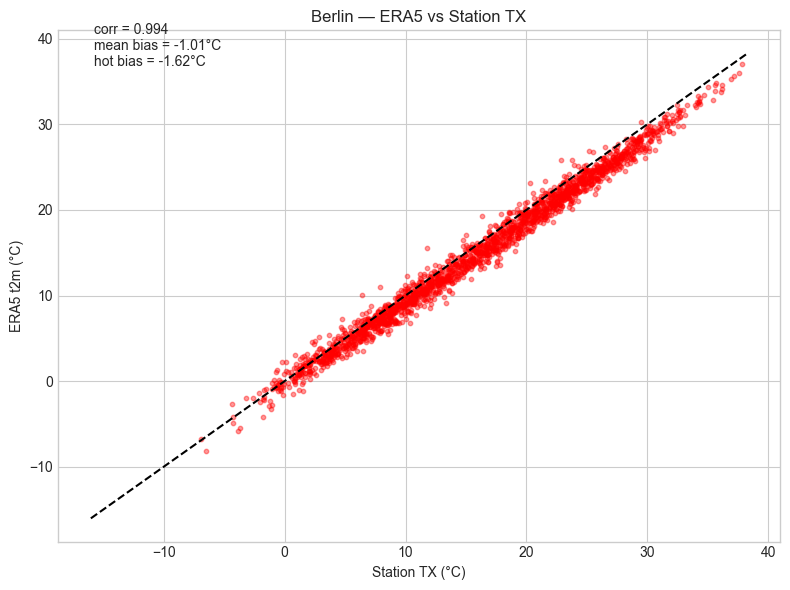

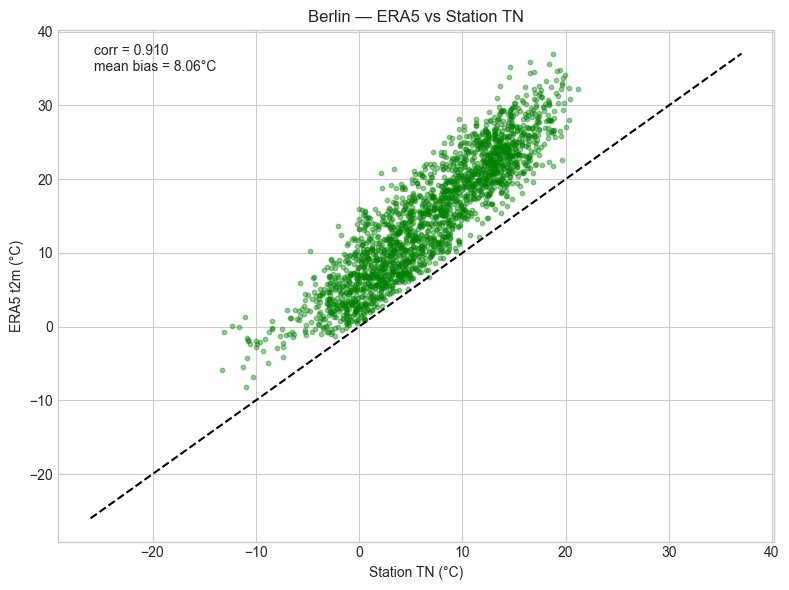

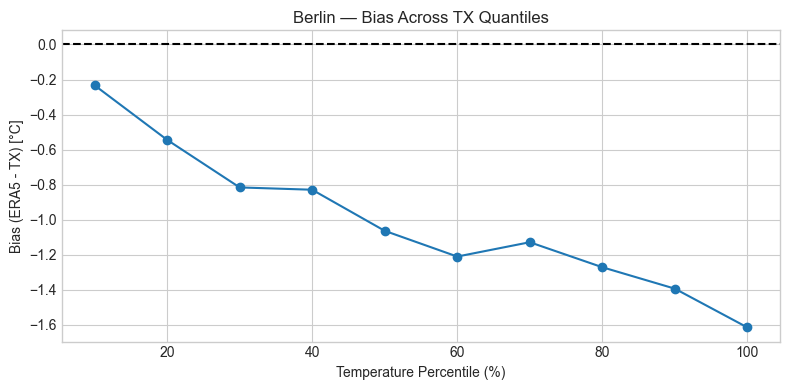

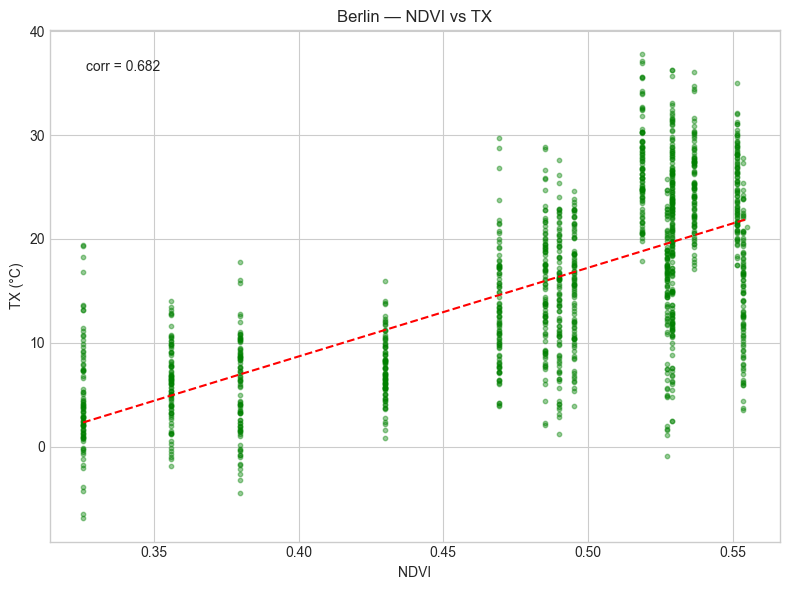

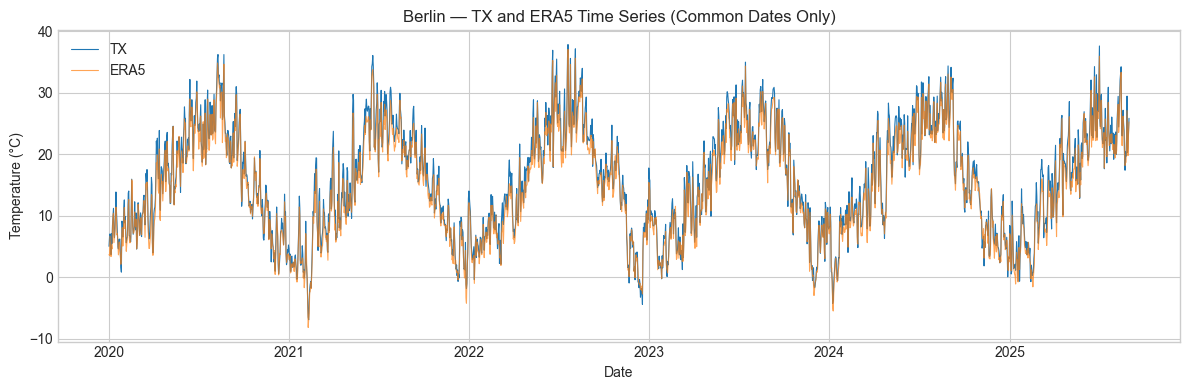

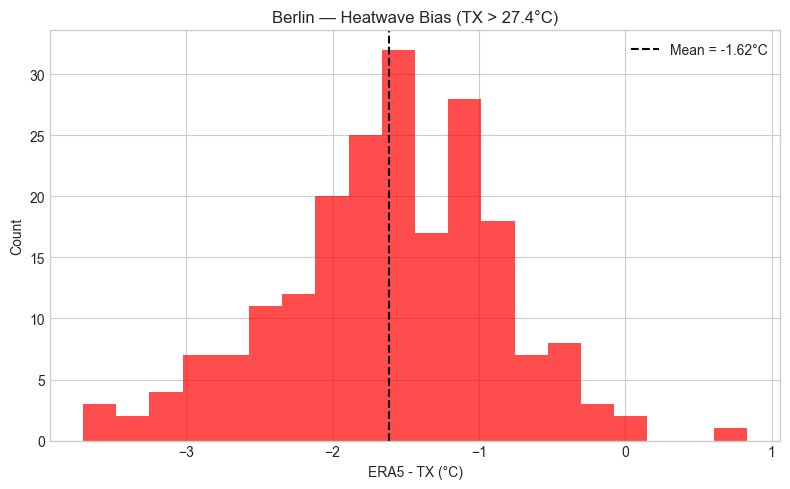

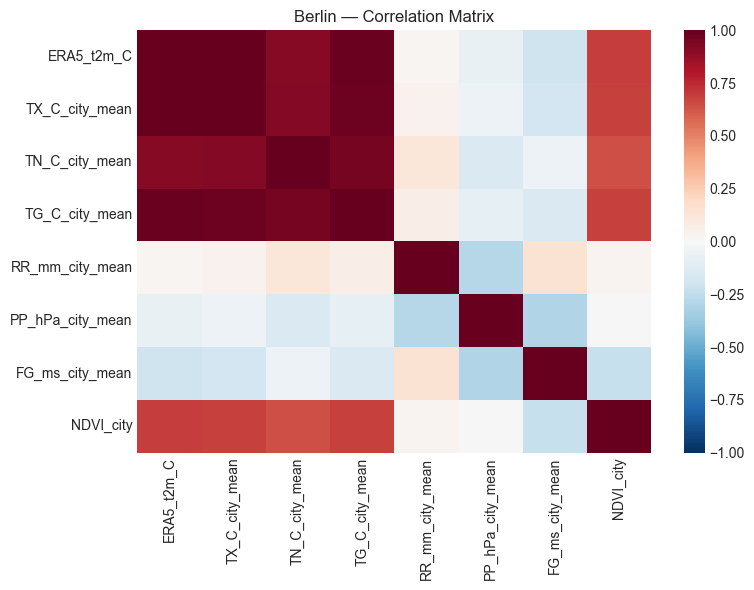

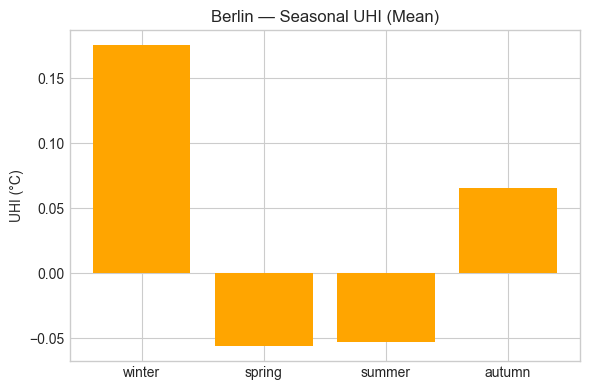


=== Processing Budapest ===


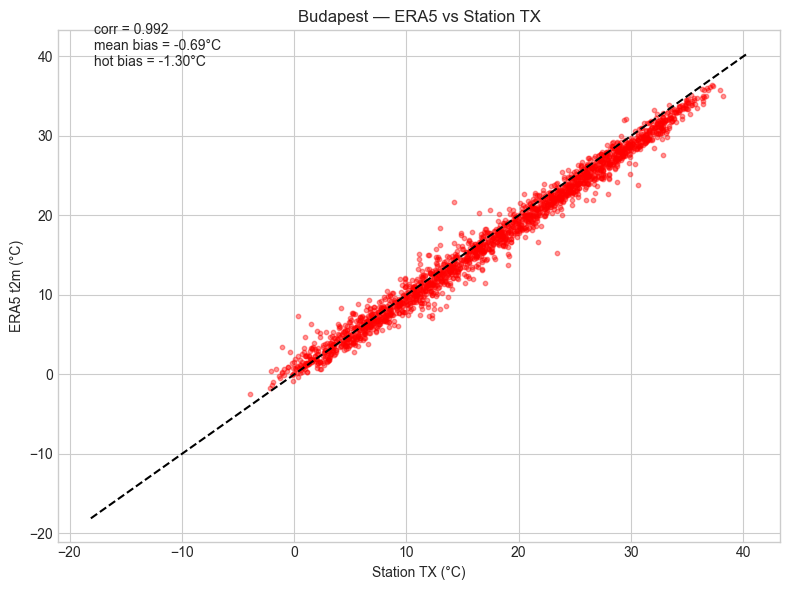

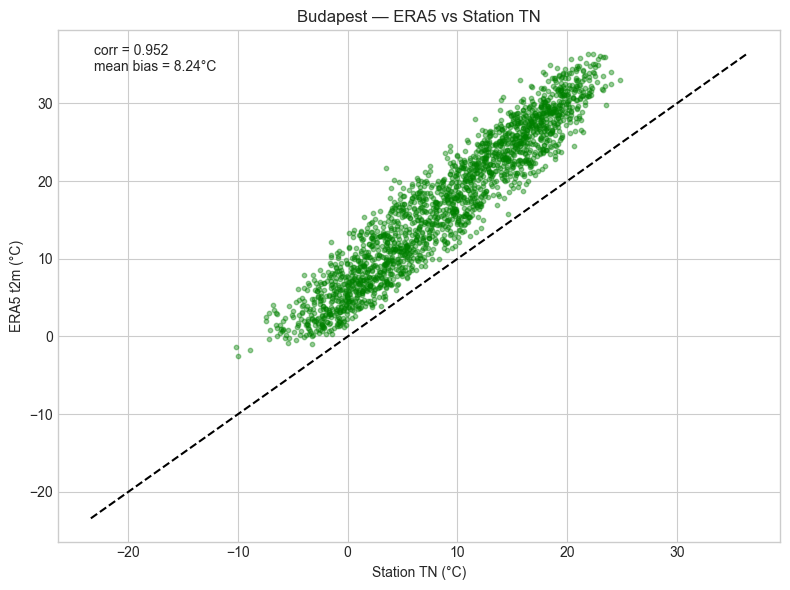

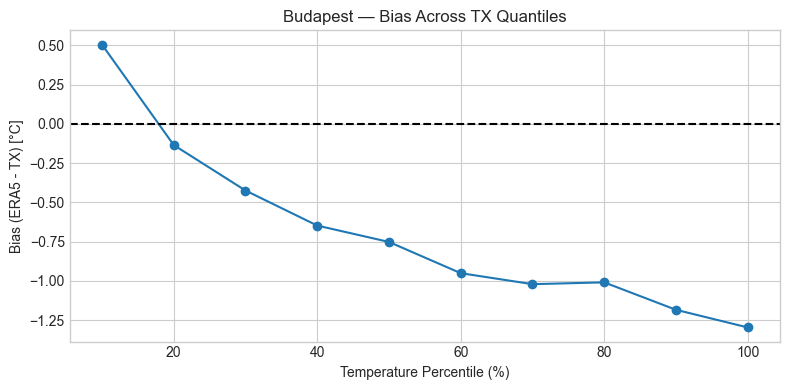

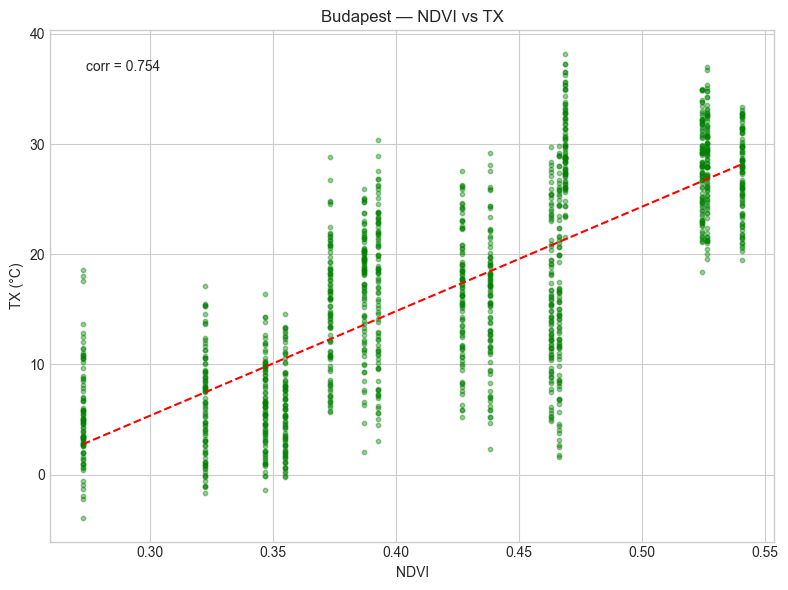

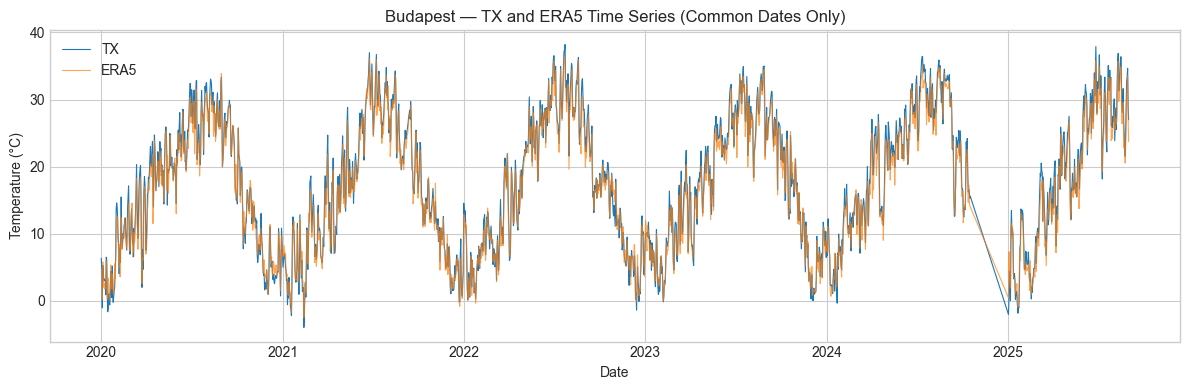

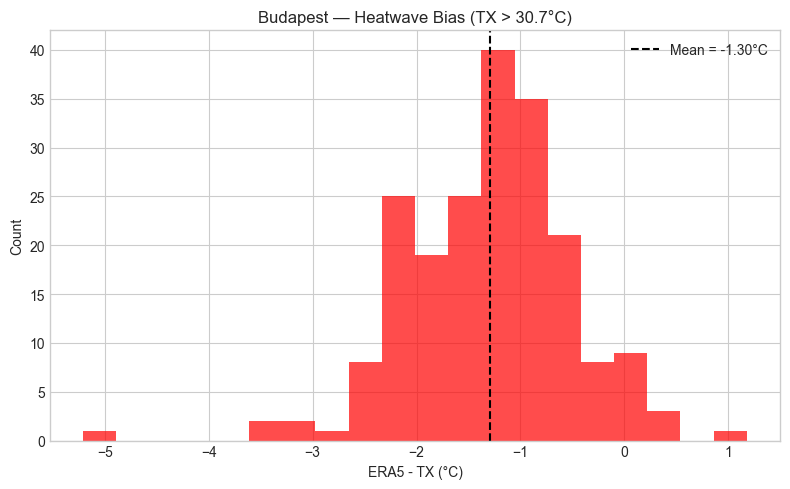

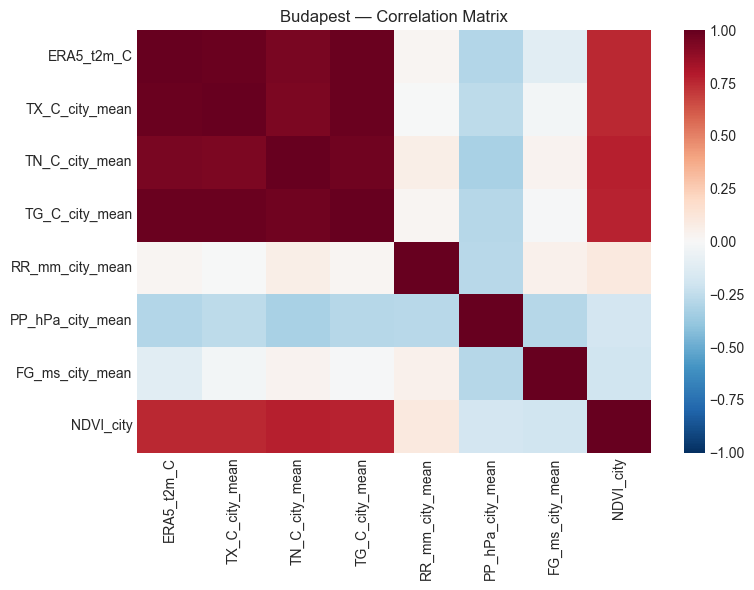

⚠ Budapest: Skipping UHI plot.

=== Processing Frankfurt ===


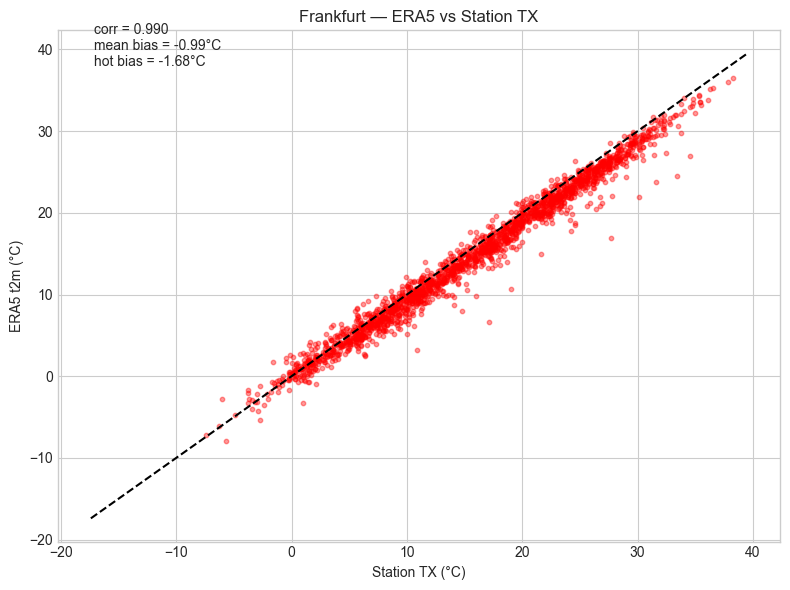

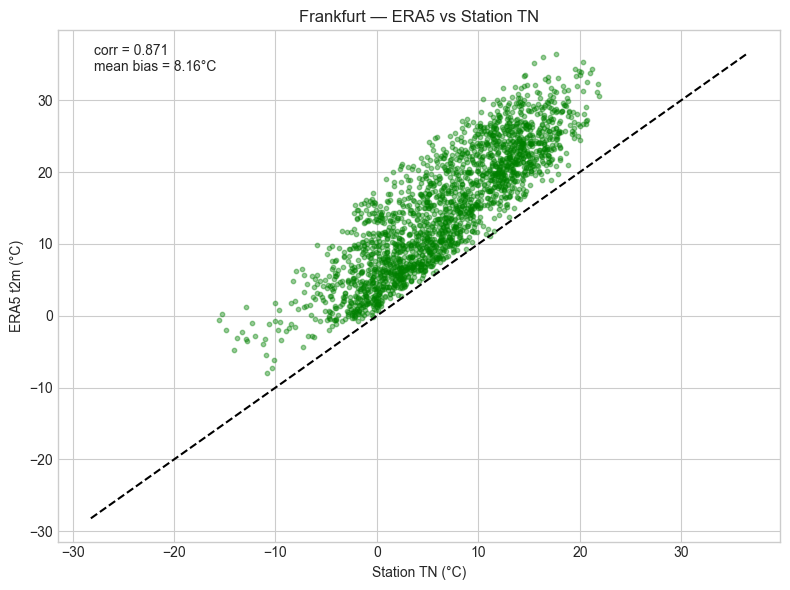

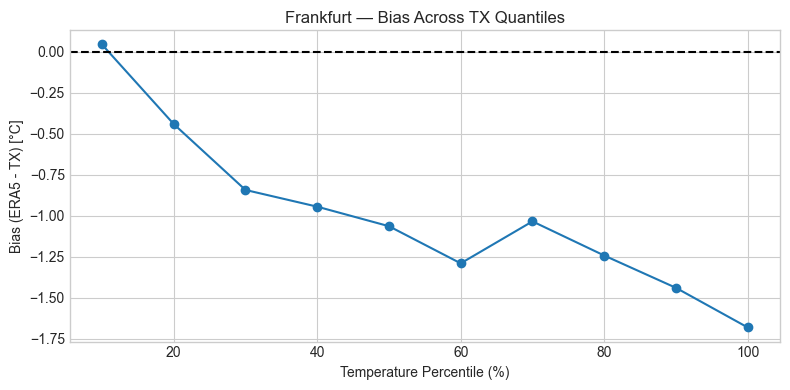

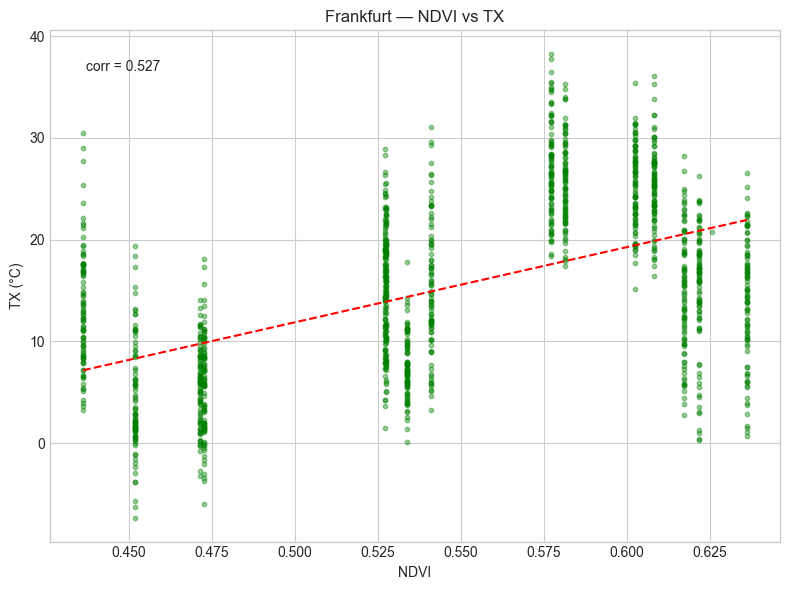

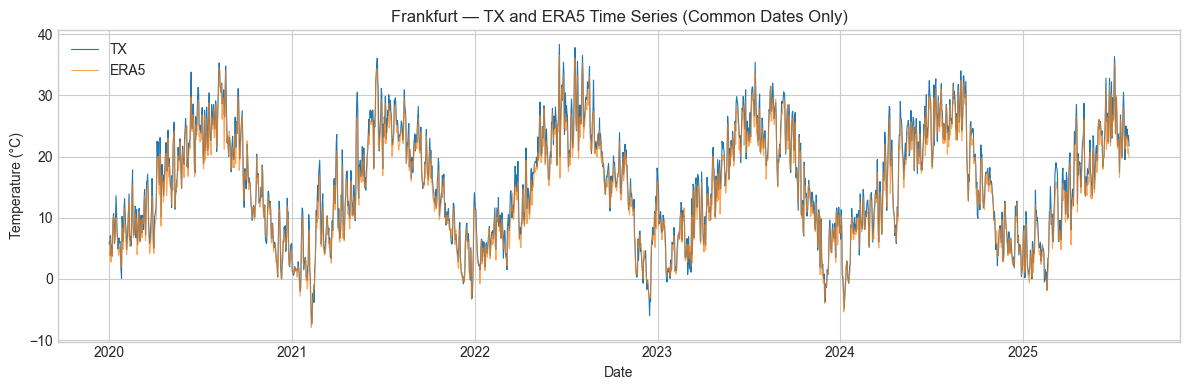

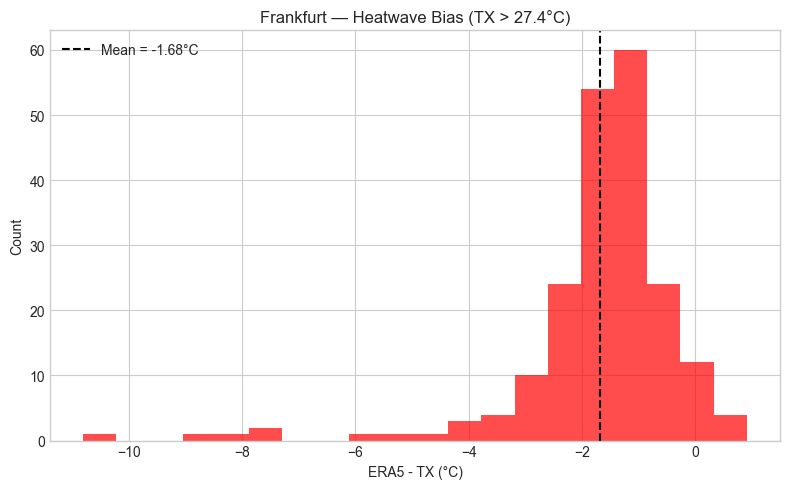

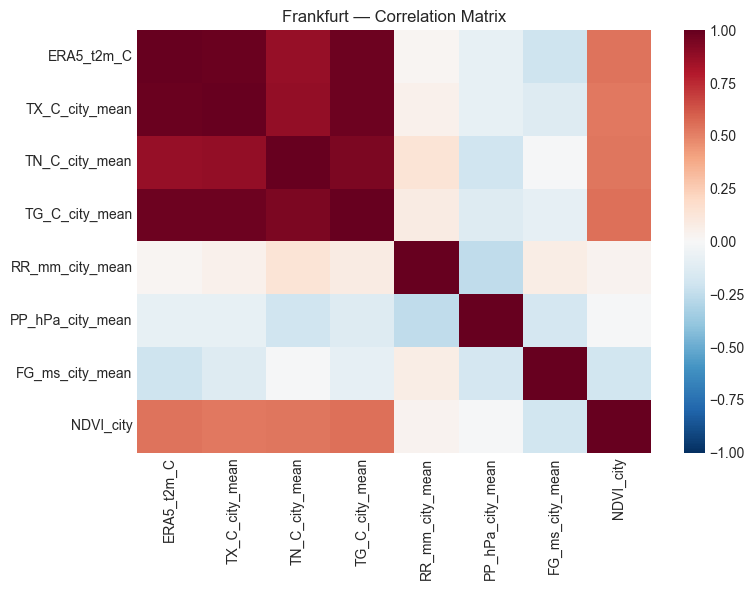

⚠ Frankfurt: Skipping UHI plot.

=== Processing Palermo ===


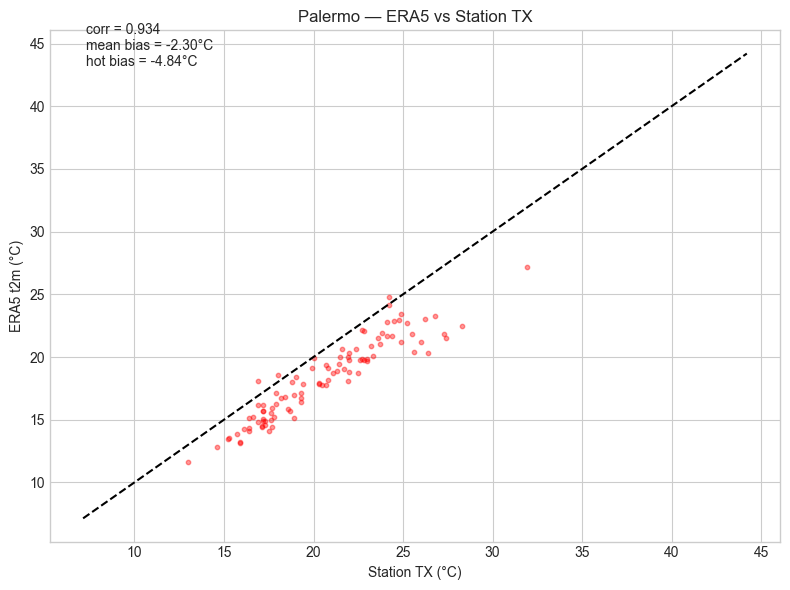

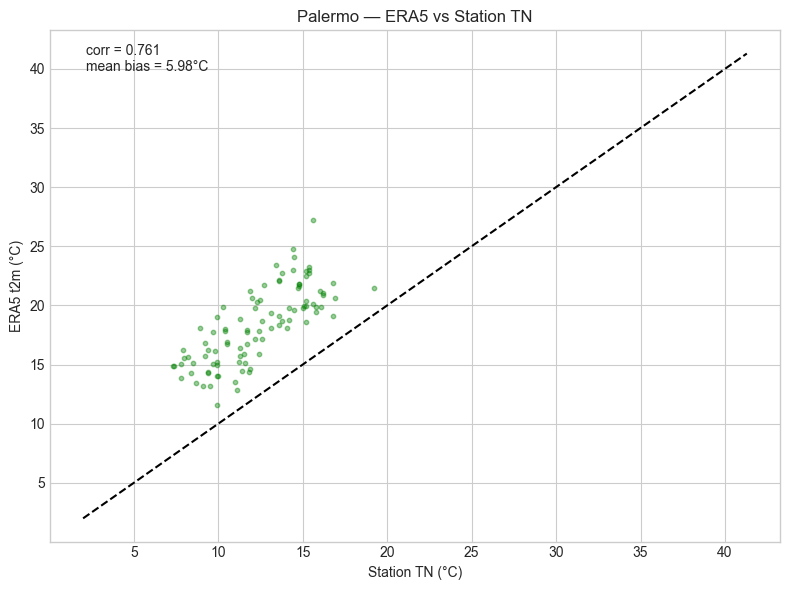

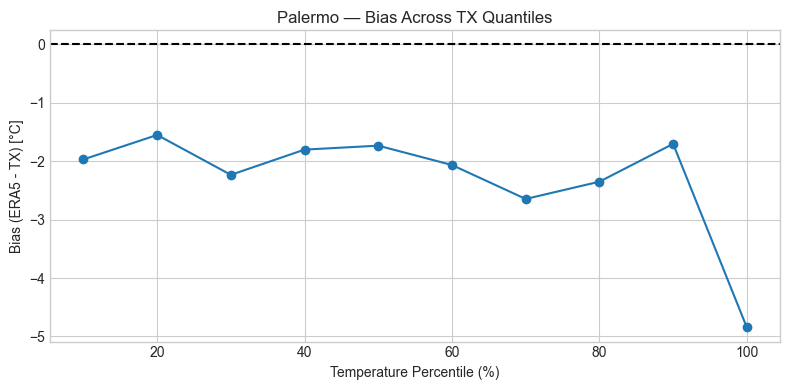

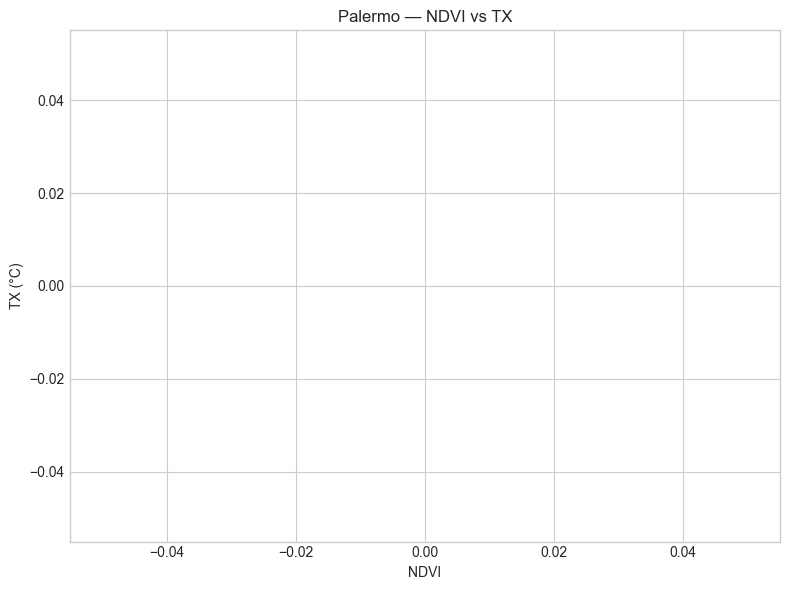

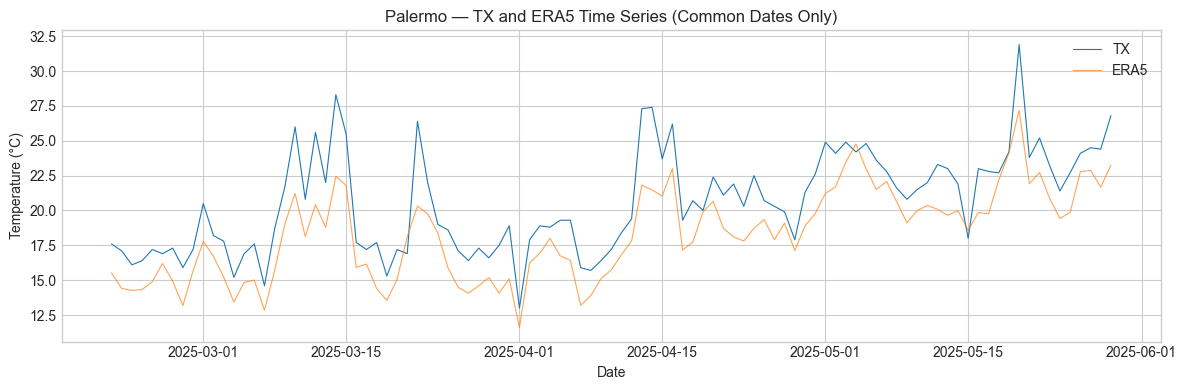

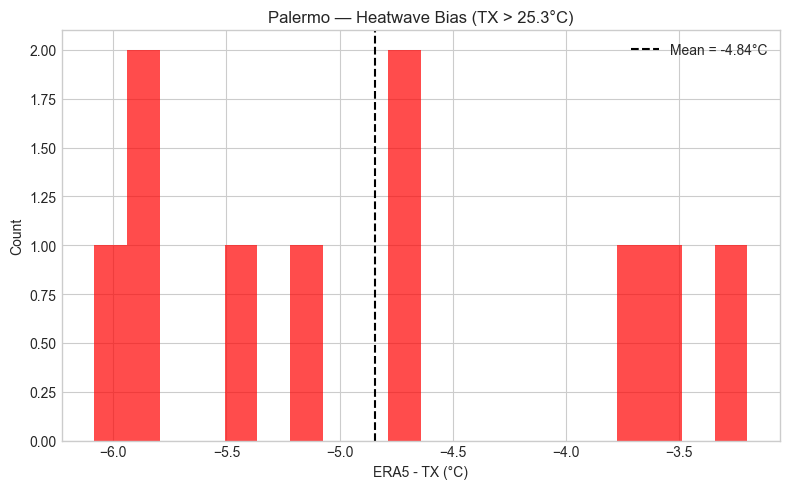

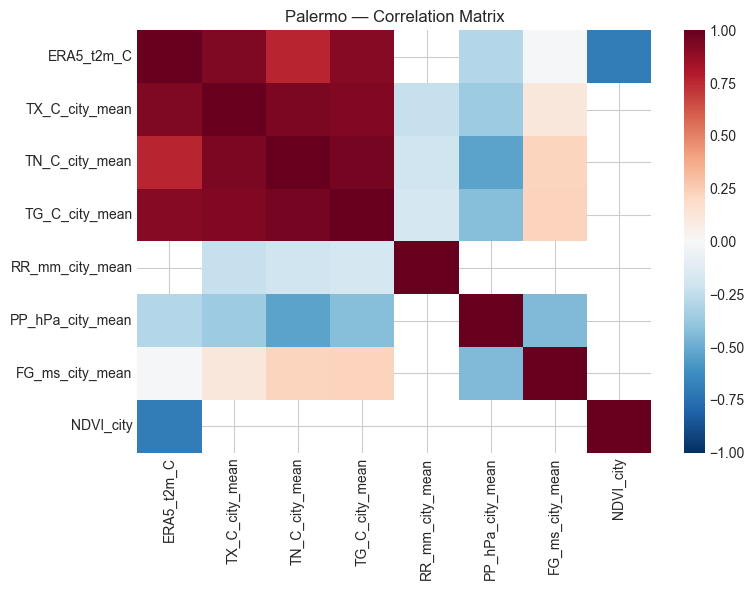

⚠ Palermo: Skipping UHI plot.

=== Processing Stockholm ===


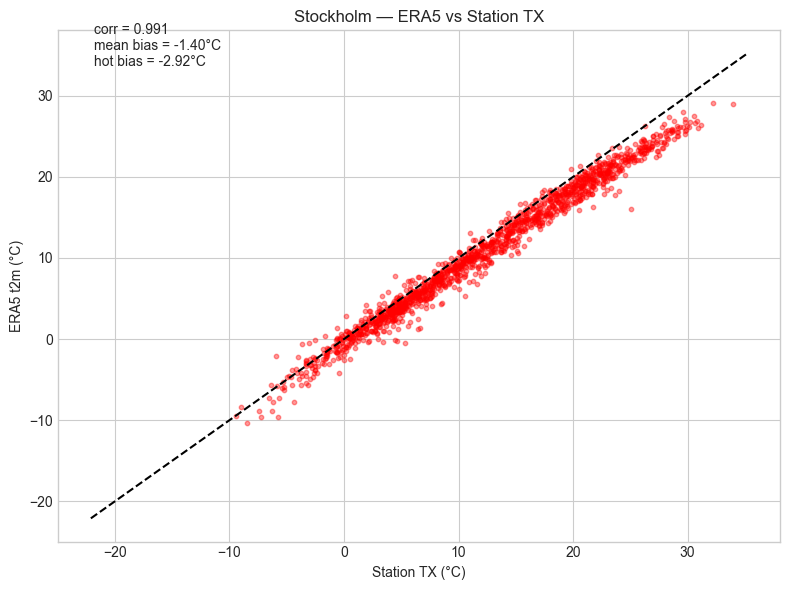

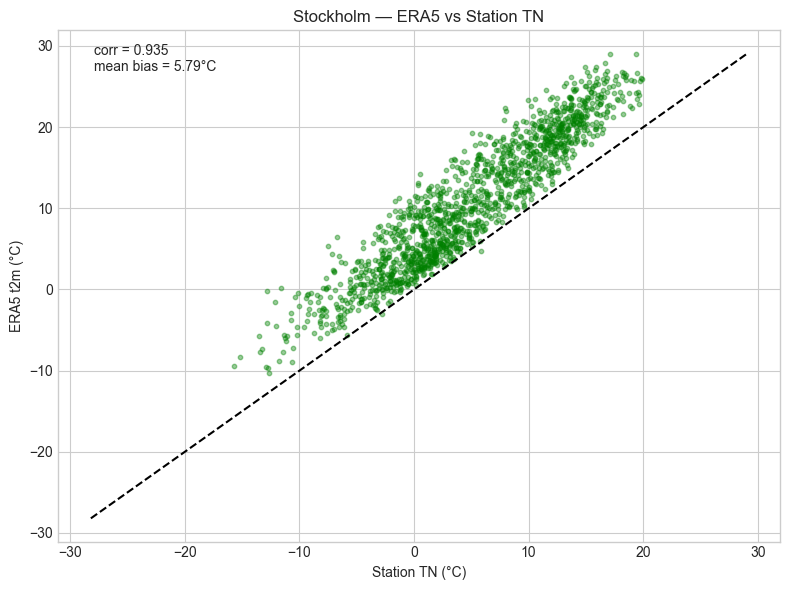

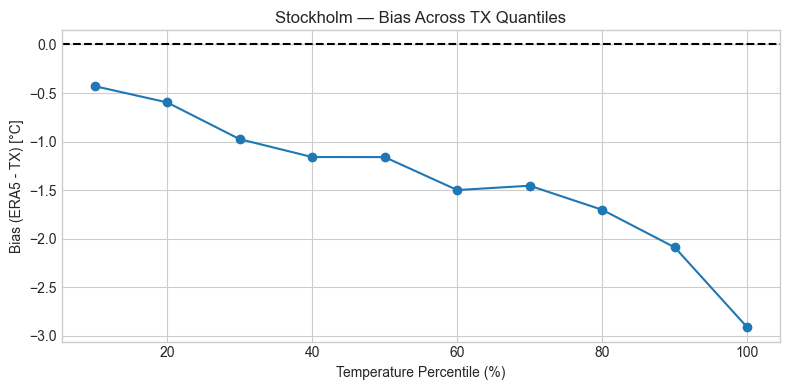

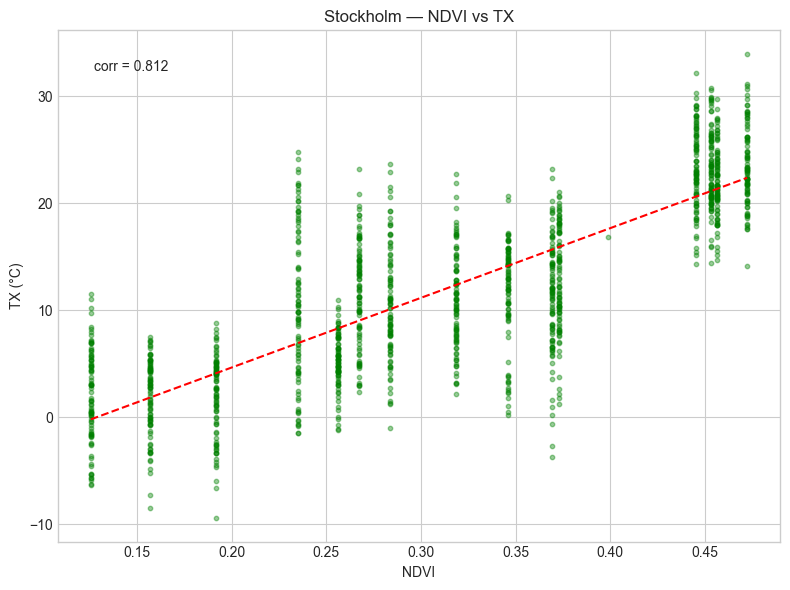

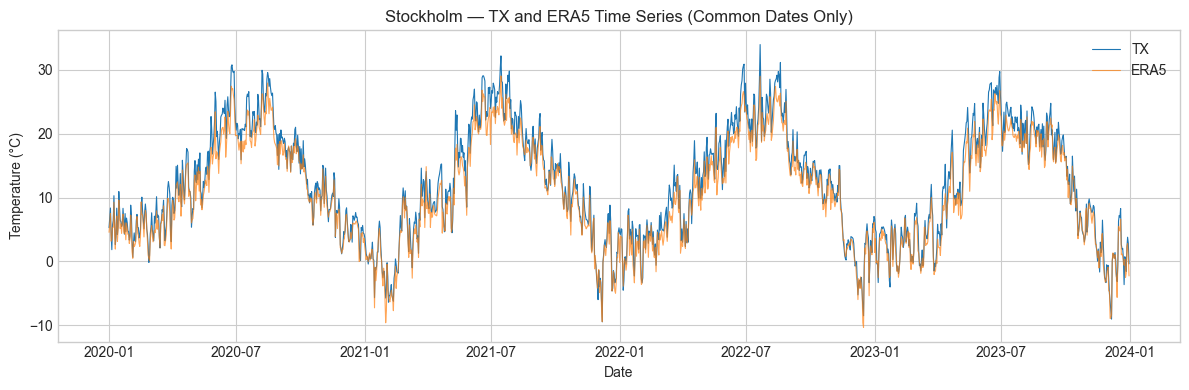

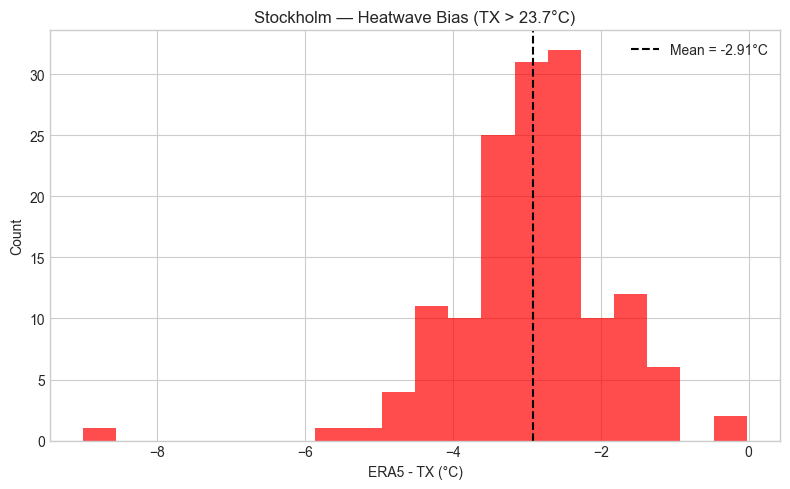

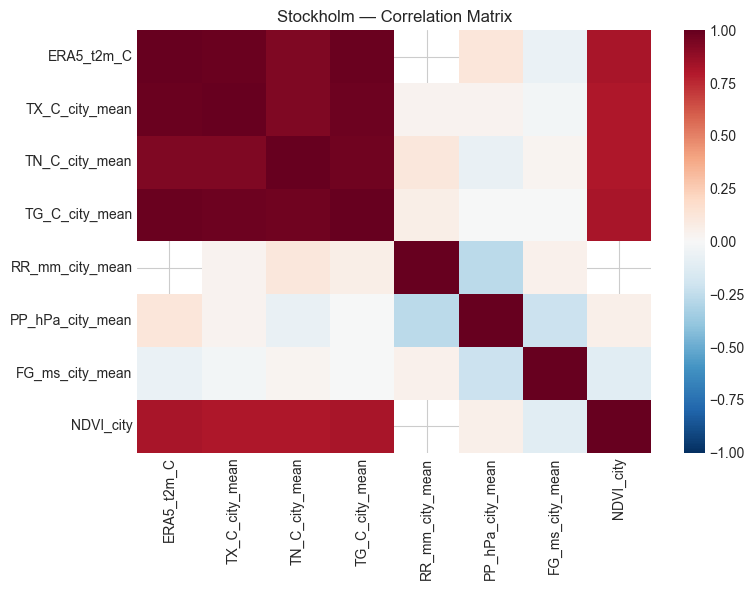

⚠ Stockholm: Skipping UHI plot.

All plots generated successfully.


In [17]:
# ===========================================================
# 4. RUN FOR ALL CITIES
# ===========================================================


for city in cities:
    generate_city_plots(city)

print("\nAll plots generated successfully.")